# Uticaj kvaliteta i predobrade tekstualnih podataka na performanse modela za klasifikaciju spam emailova

# 1. Učitavanje i osnovna analiza skupa podataka

In [126]:
import pandas as pd

df = pd.read_csv("/Users/milicamilutinovic/Downloads/emails.csv")
pd.set_option('display.max_colwidth', 200)
df.head()

,text,spam
0,Subject: naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo ...,1
1,Subject: the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or ...,1
2,"Subject: unbelievable new homes made easy im wanting to show you this homeowner you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate . this offer is being extended t...",1
3,Subject: 4 color printing special request additional information now ! click here click here for a printable version of our order form ( pdf format ) phone : ( 626 ) 338 - 8090 fax : ( 626 ) 33...,1
4,"Subject: do not have money , get software cds from here ! software compatibility . . . . ain ' t it great ? grow old along with me the best is yet to be . all tradgedies are finish ' d by death...",1


In [127]:
df.info()
df['spam'].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


spam
0    0.761173
1    0.238827
Name: proportion, dtype: float64

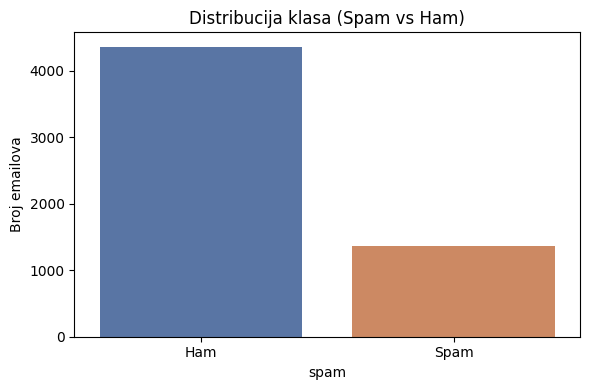

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="spam",
    hue="spam",
    data=df,
    palette=["#4C72B0", "#DD8452"],
    legend=False
)

plt.title("Distribucija klasa (Spam vs Ham)", fontsize=12)
plt.xticks([0,1], ["Ham", "Spam"])
plt.ylabel("Broj emailova")

plt.tight_layout()
plt.show()

# 2. Analiza kvaliteta teksta

### Dužina dokumenata

In [129]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

stats = df.groupby('spam')[['char_count','word_count']].agg(
    ['mean','median','std']
).round(1)

stats.index = ['Ham', 'Spam']

print("Statistike dužine dokumenata:")
display(stats)

Statistike dužine dokumenata:


char_count                 word_count              
           mean  median     std       mean median    std
Ham      1631.9  1122.0  1959.7      345.8  239.0  406.2
Spam     1317.3   693.5  2271.4      266.4  139.5  451.5

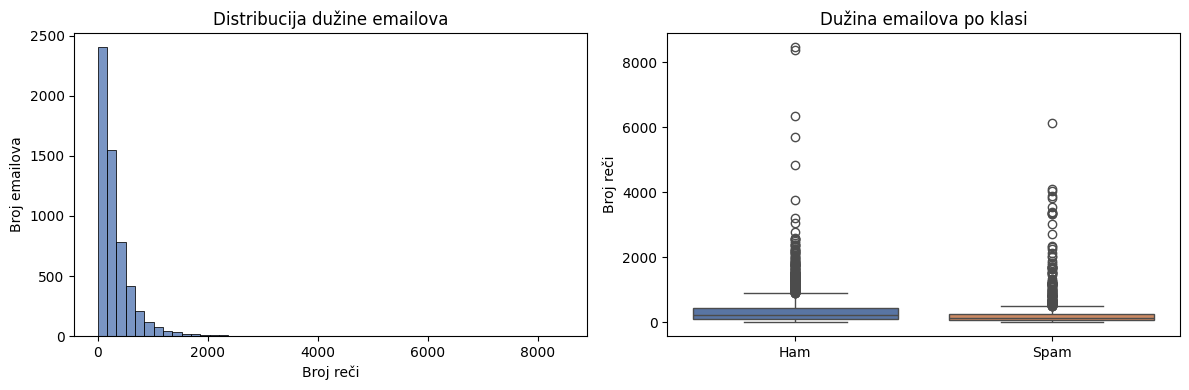

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df["word_count"], bins=50, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribucija dužine emailova")
axes[0].set_xlabel("Broj reči")
axes[0].set_ylabel("Broj emailova")

sns.boxplot(
    x="spam",
    y="word_count",
    hue="spam",
    data=df,
    palette=["#4C72B0", "#DD8452"],
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Dužina emailova po klasi")
axes[1].set_xlabel("")
axes[1].set_ylabel("Broj reči")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["Ham", "Spam"])

plt.tight_layout()
plt.show()

- Distribucija je izraženo desno asimetrična (right-skewed)
- Većina emailova ima manje od ~500 tokena
- Postoji mali broj ekstremno dugih emailova (do 8000+ tokena)

In [131]:
df.groupby("spam")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
0,4360.0,345.804817,406.189568,2.0,119.0,239.0,439.25,8477.0
1,1368.0,266.432749,451.461674,4.0,79.0,139.5,251.00,6129.0


Analiza distribucije dužine emailova pokazuje izraženu desnu asimetriju, pri čemu većina poruka sadrži manje od 500 tokena, dok mali broj ekstremno dugih poruka značajno povećava varijansu raspodele. Prosečna dužina ham poruka (345 tokena) veća je od prosečne dužine spam poruka (266 tokena), dok medijana dodatno potvrđuje da su spam poruke u tipičnom slučaju kraće. Visoke vrednosti standardne devijacije u obe klase (406 i 451) ukazuju na veliku disperziju i prisustvo outlier-a. Ovi rezultati sugerišu da dužina dokumenta sama po sebi nije dovoljan diskriminativni atribut, ali predstavlja važnu strukturnu karakteristiku koja utiče na stabilnost reprezentacije i raspodelu frekvencija u BoW i TF-IDF modelima.

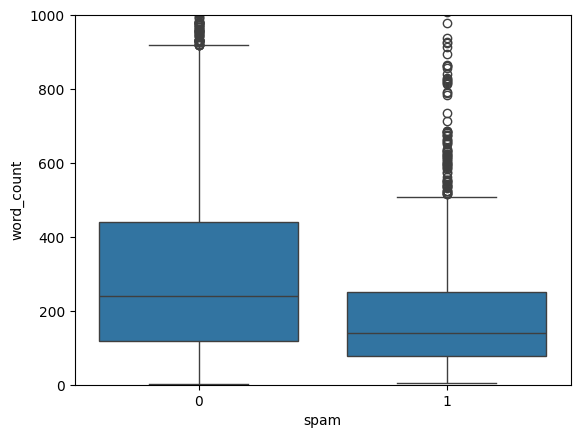

In [132]:
sns.boxplot(x="spam", y="word_count", data=df)
plt.ylim(0, 1000)
plt.show()

### Vocabulary Size (|V|)

In [133]:
from sklearn.feature_extraction.text import CountVectorizer

# Ukupan vokabular
vectorizer_all = CountVectorizer()
X_all = vectorizer_all.fit_transform(df["text"])
all_vocab = set(vectorizer_all.get_feature_names_out())

# Spam vokabular
vectorizer_spam = CountVectorizer()
X_spam = vectorizer_spam.fit_transform(df[df["spam"] == 1]["text"])
spam_vocab = set(vectorizer_spam.get_feature_names_out())

# Ham vokabular
vectorizer_ham = CountVectorizer()
X_ham = vectorizer_ham.fit_transform(df[df["spam"] == 0]["text"])
ham_vocab = set(vectorizer_ham.get_feature_names_out())

print("Vocabulary Size: ")
print(f"Ukupan vokabular:     {len(all_vocab):,} tokena")
print(f"Spam vokabular:       {len(spam_vocab):,} tokena")
print(f"Ham vokabular:        {len(ham_vocab):,} tokena")
print(f"Presek (zajednički):  {len(spam_vocab & ham_vocab):,} tokena")
print(f"Samo u spamu:         {len(spam_vocab - ham_vocab):,} tokena")
print(f"Samo u hamu:          {len(ham_vocab - spam_vocab):,} tokena")

Vocabulary Size: 
Ukupan vokabular:     37,303 tokena
Spam vokabular:       18,774 tokena
Ham vokabular:        27,074 tokena
Presek (zajednički):  8,545 tokena
Samo u spamu:         10,229 tokena
Samo u hamu:          18,529 tokena


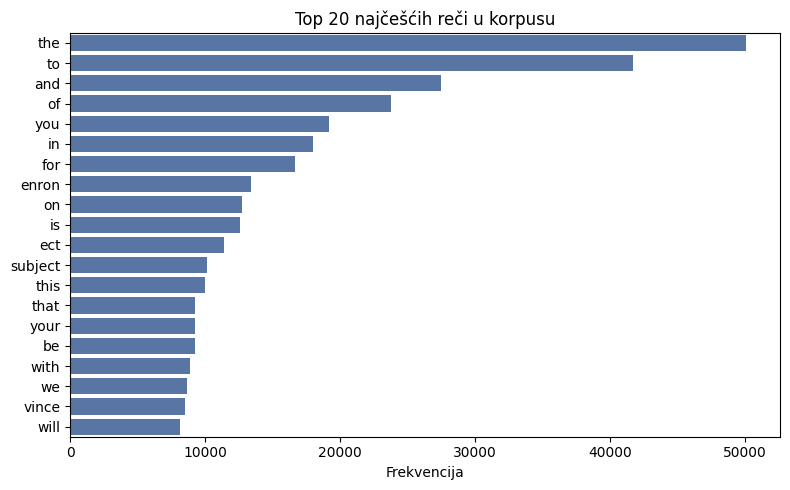

In [134]:
# Suma frekvencija po rečima
sum_words = X_all.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer_all.vocabulary_.items()
]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

top_words = pd.DataFrame(words_freq[:20], columns=["reč", "frekvencija"])

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_words,
    x="frekvencija",
    y="reč",
    color="#4C72B0"
)

plt.title("Top 20 najčešćih reči u korpusu")
plt.xlabel("Frekvencija")
plt.ylabel("")

plt.tight_layout()
plt.show()

Ukupna veličina vokabulara iznosi 37.303 jedinstvena tokena, što u odnosu na 5728 dokumenata implicira visoku dimenzionalnost reprezentacionog prostora. Distribucija frekvencija reči potvrđuje Zipfov zakon — mali broj reči ima izuzetno visoku frekvenciju, dok veliki broj tokena ima veoma nisku frekvenciju. Ovakva raspodela dovodi do izrazite retkosti (sparsity) matrice karakteristika u BoW reprezentaciji, što povećava varijansu modela i zahteva primenu redukcije dimenzionalnosti ili regularizacije.

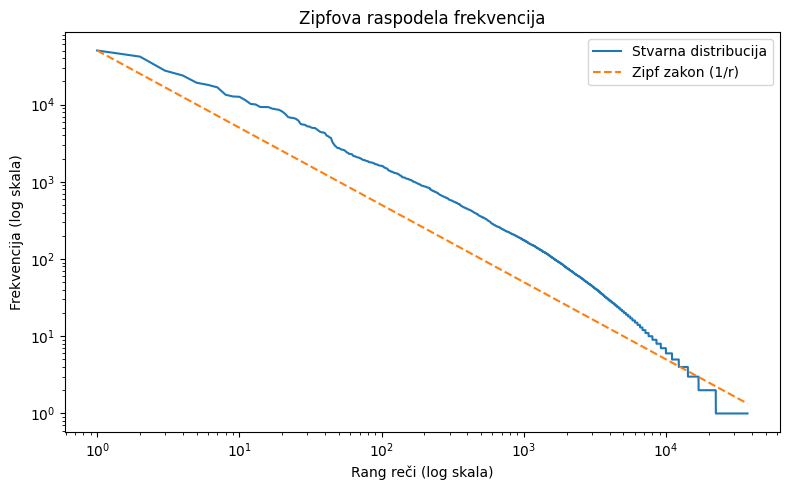

In [135]:
import numpy as np
freqs = [freq for word, freq in words_freq]

ranks = np.arange(1, len(freqs) + 1)

# Teorijska Zipf linija (skalirana po prvoj vrednosti)
s = 1.0  
C = freqs[0]

zipf_theoretical = C / (np.array(ranks) ** s)

plt.figure(figsize=(8,5))

plt.loglog(ranks, freqs, label="Stvarna distribucija")
plt.loglog(ranks, zipf_theoretical, linestyle="--", label="Zipf zakon (1/r)")

plt.title("Zipfova raspodela frekvencija")
plt.xlabel("Rang reči (log skala)")
plt.ylabel("Frekvencija (log skala)")
plt.legend()

plt.tight_layout()
plt.show()

In [136]:
vocab_size = len(all_vocab)

rare_words = sum(1 for word, freq in words_freq if freq == 1)

print("Broj reči sa frekvencijom 1:", rare_words)
print("Procenat retkih reči: {:.2%}".format(rare_words / vocab_size))

Broj reči sa frekvencijom 1: 14987
Procenat retkih reči: 40.18%


more than 40% = Long-tail efekat

### Lexical Diversity

In [137]:
def lexical_diversity(text):
    tokens = str(text).split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df["lexical_diversity"] = df["text"].apply(lexical_diversity)

In [138]:
df.groupby("spam")["lexical_diversity"].describe()

,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
0,4360.0,0.532707,0.164065,0.051325,0.406303,0.514228,0.648121,1.0
1,1368.0,0.623567,0.171078,0.172821,0.482759,0.638665,0.762712,1.0


In [139]:
df.groupby("spam")["lexical_diversity"].mean()

spam
0    0.532707
1    0.623567
Name: lexical_diversity, dtype: float64

In [140]:
df[["word_count", "lexical_diversity"]].corr()

,word_count,lexical_diversity
word_count,1.000000,-0.612319
lexical_diversity,-0.612319,1.000000


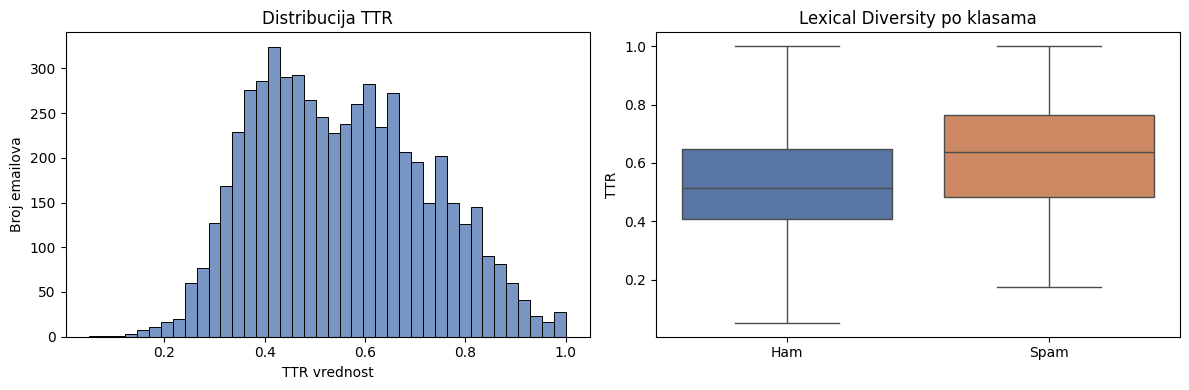

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Distribucija TTR
sns.histplot(df["lexical_diversity"], bins=40, color="#4C72B0", ax=axes[0])
axes[0].set_title("Distribucija TTR")
axes[0].set_xlabel("TTR vrednost")
axes[0].set_ylabel("Broj emailova")

# TTR po klasama
sns.boxplot(
    x="spam",
    y="lexical_diversity",
    hue="spam",
    data=df,
    palette=["#4C72B0", "#DD8452"],
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Lexical Diversity po klasama")
axes[1].set_xlabel("")
axes[1].set_ylabel("TTR")
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(["Ham", "Spam"])

plt.tight_layout()
plt.show()

Analiza leksičke raznovrsnosti pokazuje da spam poruke imaju višu prosečnu vrednost Tip-Token Ratio metrike (0.62) u odnosu na legitimne poruke (0.53), što ukazuje na veći broj jedinstvenih tokena u odnosu na ukupnu dužinu dokumenta. Ovakav rezultat može sugerisati upotrebu varijacija reči, obfuskaciju i generisanje dodatnog sadržaja radi zaobilaženja spam filtera.

Međutim, analiza korelacije između dužine dokumenta i lexical diversity pokazuje značajnu negativnu korelaciju (r = -0.61), što potvrđuje da Tip-Token Ratio zavisi od dužine teksta. Duži dokumenti prirodno sadrže više ponavljanja, što smanjuje vrednost TTR metrike. Zato što su spam poruke u proseku kraće, deo razlike u leksičkoj raznovrsnosti može biti posledica ove strukturne karakteristike, a ne isključivo sadržajnih razlika između klasa.

Ovi rezultati ukazuju da lexical diversity predstavlja potencijalno diskriminativan signal, ali ga treba interpretirati u kontekstu dužine dokumenta i koristiti u kombinaciji sa drugim karakteristikama.

### Analiza šuma

In [142]:
import re
def count_urls(text):
    return len(re.findall(r'http[s]?://\S+|www\.\S+', str(text)))

def count_emails(text):
    return len(re.findall(r'[\w.+-]+@[\w-]+\.[\w.]+', str(text)))

def count_html_tags(text):
    return len(re.findall(r'<[^>]+>', str(text)))

def count_numbers(text):
    return len(re.findall(r'\b\d+\b', str(text)))

def count_caps_words(text):
    words = str(text).split()
    return sum(1 for w in words if w.isupper() and len(w) > 2)

def count_special_chars(text):
    return len(re.findall(r'[!$%&*@#]', str(text)))

def has_obfuscation(text):
    # Deformisane reči poput fr33, cl1ck
    return int(bool(re.search(r'[a-z]+\d+[a-z]+|[a-z]\d[a-z]', str(text).lower())))

df['url_count'] = df['text'].apply(count_urls)
df['email_count'] = df['text'].apply(count_emails)
df['html_count'] = df['text'].apply(count_html_tags)
df['number_count'] = df['text'].apply(count_numbers)
df['caps_count'] = df['text'].apply(count_caps_words)
df['special_chars'] = df['text'].apply(count_special_chars)
df['has_obfuscation'] = df['text'].apply(has_obfuscation)

noise_cols = ['url_count','email_count','html_count','number_count',
              'caps_count','special_chars','has_obfuscation']

print(' Analiza šuma po klasama (srednje vrednosti): ')
noise_stats = df.groupby("spam")[noise_cols].mean().round(2)
noise_stats.index = ["Ham", "Spam"]

display(noise_stats)

 Analiza šuma po klasama (srednje vrednosti): 


,url_count,email_count,html_count,number_count,caps_count,special_chars,has_obfuscation
Ham,0.0,0.0,0.0,17.14,0.0,5.98,0.0
Spam,0.0,0.0,0.0,10.94,0.0,6.39,0.0


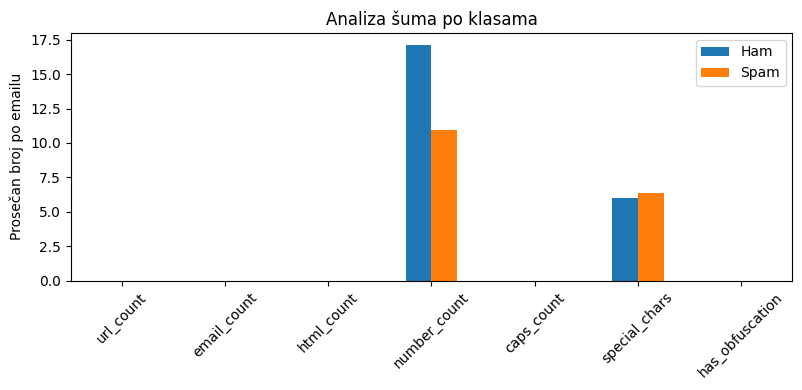

In [143]:
import matplotlib.pyplot as plt

noise_stats.T.plot(kind="bar", figsize=(8,4))

plt.title("Analiza šuma po klasama")
plt.ylabel("Prosečan broj po emailu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Uočava se da su brojevi i specijalni znaci najizraženiji oblici šuma u obe klase. Ham poruke sadrže veći prosečan broj numeričkih tokena, dok spam poruke pokazuju nešto veću upotrebu specijalnih znakova. Ostale karakteristike (URL, email, HTML tagovi, CAPS reči i obfuskacija) imaju zanemarljivu prosečnu vrednost.
Ovi rezultati ukazuju da numerički i simbolički obrasci mogu predstavljati korisne indikatore pri modeliranju, ali sami po sebi nisu dovoljni za pouzdanu klasifikaciju.

### Korelaciona matrica

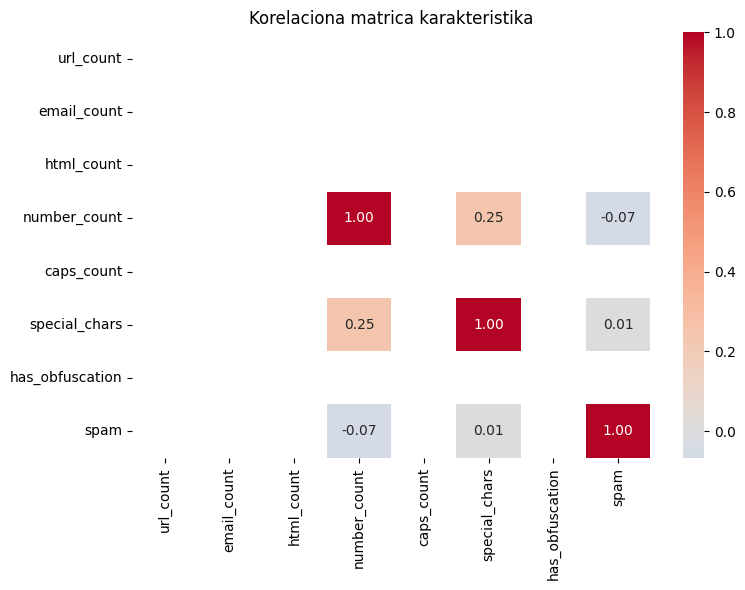

In [144]:

corr_matrix = df[noise_cols + ['spam']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Korelaciona matrica karakteristika")
plt.tight_layout()
plt.show()

Korelaciona matrica pokazuje da su sve pojedinačne karakteristike šuma slabo povezane sa spam klasom. Najizraženija međusobna korelacija primećena je između broja numeričkih tokena i specijalnih znakova (r ≈ 0.25), ali njihova povezanost sa klasom spam ostaje minimalna.
Ovo ukazuje da izolovane karakteristike nisu dovoljne za pouzdanu klasifikaciju, već je potrebna kombinacija više atributa i model koji može da uhvati kompleksnije obrasce.

# 3. Predobrada teksta

### Tokenizacija

Tokenizacija predstavlja proces razlaganja teksta na manje jedinice (tokene), najčešće reči. U ovom radu koristi se jednostavna word-level tokenizacija zasnovana na razdvajanju po razmacima.

In [145]:
# Word tokenizacija (regex)
def tokenize_words(text):
    return re.findall(r"\b[a-zA-Z]+\b", str(text).lower())

# Sentence tokenizacija
def tokenize_sentences(text):
    sentences = re.split(r"[.!?]+", str(text))
    return [s.strip() for s in sentences if len(s.strip()) > 10]

# Pojednostavljena subword tokenizacija
def tokenize_subword(text):
    tokens = tokenize_words(text)
    sub_tokens = []
    for t in tokens:
        if len(t) <= 4:
            sub_tokens.append(t)
        else:
            sub_tokens.extend([t[:3] + "##", "##" + t[3:]])
    return sub_tokens


# Primer demonstracije
sample_text = df["text"].iloc[0]

print("Original (skraćeno):")
print(sample_text[:200])
print("\nWord tokens:", tokenize_words(sample_text)[:15])
print("\nSentence tokens:", tokenize_sentences(sample_text)[:3])
print("\nSubword tokens:", tokenize_subword(sample_text)[:15])

Original (skraćeno):
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , st

Word tokens: ['subject', 'naturally', 'irresistible', 'your', 'corporate', 'identity', 'lt', 'is', 'really', 'hard', 'to', 'recollect', 'a', 'company', 'the']

Sentence tokens: ['Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier', 'we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective', 'her

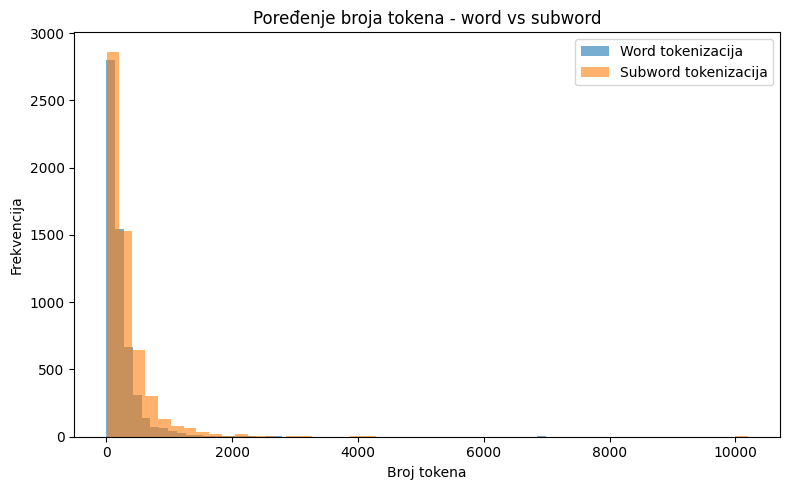

Poređenje tokenizacionih pristupa

Word tokenizacija       prosečan broj tokena: 227.8
Subword tokenizacija    prosečan broj tokena: 327.4
Sentence tokenizacija   prosečan broj rečenica: 15.1
Povećanje broja tokena (subword vs word): 43.7%


In [146]:
word_token_counts = df['text'].apply(lambda x: len(tokenize_words(x)))
subword_token_counts = df['text'].apply(lambda x: len(tokenize_subword(x)))
sent_counts = df['text'].apply(lambda x: len(tokenize_sentences(x)))
plt.figure(figsize=(8,5))

plt.hist(word_token_counts, bins=50, alpha=0.6, label="Word tokenizacija")
plt.hist(subword_token_counts, bins=50, alpha=0.6, label="Subword tokenizacija")

plt.title("Poređenje broja tokena - word vs subword")
plt.xlabel("Broj tokena")
plt.ylabel("Frekvencija")
plt.legend()

plt.tight_layout()
plt.show()
print("Poređenje tokenizacionih pristupa\n")

print(f"Word tokenizacija       prosečan broj tokena: {word_token_counts.mean():.1f}")
print(f"Subword tokenizacija    prosečan broj tokena: {subword_token_counts.mean():.1f}")
print(f"Sentence tokenizacija   prosečan broj rečenica: {sent_counts.mean():.1f}")
print(f"Povećanje broja tokena (subword vs word): "
      f"{(subword_token_counts.mean()/word_token_counts.mean()-1)*100:.1f}%")

Rezultati pokazuju jasnu razliku između word-level i subword tokenizacije.

Prosečan broj tokena po dokumentu iznosi 227.8 kod word tokenizacije, dok subword pristup generiše 327.4 tokena po dokumentu, što predstavlja povećanje od približno 43.7%.

Ovo povećanje je očekivano, jer subword tokenizacija razlaže duže reči na manje segmente, čime se povećava ukupna dužina sekvence. Iako to povećava ulaznu dimenzionalnost,omogućava bolju obradu retkih i nepoznatih reči.

Sentence tokenizacija pokazuje da prosečan email sadrži oko 15 rečenica, što potvrđuje relativno složenu strukturu poruka u korpusu.

### Normalizacija teksta

Za normalizaciju teksta implementirana je parametrizovana funkcija koja omogućava
kontrolu pojedinačnih koraka predobrade.

Primijenjeni postupci uključuju:

- Unicode NFKC standardizaciju karaktera  
- uklanjanje HTML tagova  
- zamenu URL-ova tokenom `<URL>`  
- zamenu email adresa tokenom `<EMAIL>`  
- zamenu numeričkih vrednosti tokenom `<NUMBER>`  
- transformaciju teksta u mala slova  
- opciono uklanjanje interpunkcije  

Za razliku od potpunog uklanjanja određenih elemenata, korišćena je strategija
zamene specijalnim tokenima, čime se zadržava informacija o njihovom prisustvu
uz istovremeno smanjenje varijabilnosti zapisa.

Ovakav pristup omogućava smanjenje šuma, ali i očuvanje potencijalno
diskriminativnih obrazaca važnih za klasifikaciju.

In [147]:
import unicodedata
import string

def normalize_text(text):
    text = str(text)
    
    # Unicode normalizacija
    text = unicodedata.normalize("NFKC", text)
    
    # HTML tagovi
    text = re.sub(r"<[^>]+>", " ", text)
    
    # URL → <URL>
    text = re.sub(r"http[s]?://\S+|www\.\S+", " <URL> ", text)
    
    # Email → <EMAIL>
    text = re.sub(r"[\w.+-]+@[\w-]+\.[\w.]+", " <EMAIL> ", text)
    
    # Brojevi → <NUMBER>
    text = re.sub(r"\b\d+\.?\d*\b", " <NUMBER> ", text)
    
    # Lowercase
    text = text.lower()
    
    # Uklanjanje interpunkcije (osim < i > zbog tokena)
    text = re.sub(r"[^\w\s<>]", " ", text)
    
    # Uklanjanje viška razmaka
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [148]:
df["text_normalized"] = df["text"].apply(normalize_text)

df[["text", "text_normalized"]].head()

,text,text_normalized
0,Subject: naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo ...,subject naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwhelminq but a good catchy logo stylish ...
1,Subject: the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or ...,subject the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or co...
2,"Subject: unbelievable new homes made easy im wanting to show you this homeowner you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate . this offer is being extended t...",subject unbelievable new homes made easy im wanting to show you this homeowner you have been pre approved for a <number> <number> home loan at a <number> <number> fixed rate this offer is being ex...
3,Subject: 4 color printing special request additional information now ! click here click here for a printable version of our order form ( pdf format ) phone : ( 626 ) 338 - 8090 fax : ( 626 ) 33...,subject <number> color printing special request additional information now click here click here for a printable version of our order form pdf format phone <number> <number> <number> fax <number> ...
4,"Subject: do not have money , get software cds from here ! software compatibility . . . . ain ' t it great ? grow old along with me the best is yet to be . all tradgedies are finish ' d by death...",subject do not have money get software cds from here software compatibility ain t it great grow old along with me the best is yet to be all tradgedies are finish d by death all comedies are ended ...


In [149]:
df["length_before"] = df["text"].str.len()
df["length_after"] = df["text_normalized"].str.len()

print("Prosečna dužina pre:", round(df["length_before"].mean(), 1))
print("Prosečna dužina posle:", round(df["length_after"].mean(), 1))
print("Prosečno smanjenje:",
      round(df["length_before"].mean() - df["length_after"].mean(), 1))

Prosečna dužina pre: 1556.8
Prosečna dužina posle: 1459.6
Prosečno smanjenje: 97.2


In [150]:
def vocab_size(texts):
    vec = CountVectorizer()
    X = vec.fit_transform(texts)
    return len(vec.vocabulary_)

vocab_sizes = {
    "Bez normalizacije": vocab_size(df["text"]),
    "Sa normalizacijom": vocab_size(df["text"].apply(normalize_text))
}

print("=== Uticaj normalizacije na veličinu vokabulara ===")
for name, size in vocab_sizes.items():
    print(f"{name:20s}: {size:,} tokena")

=== Uticaj normalizacije na veličinu vokabulara ===
Bez normalizacije   : 37,303 tokena
Sa normalizacijom   : 33,688 tokena


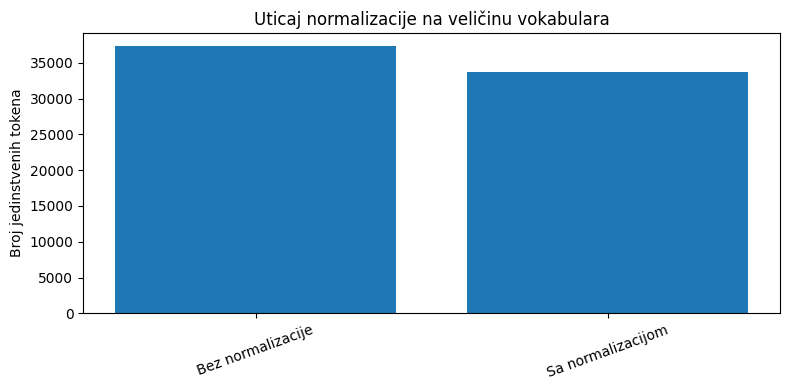

In [151]:
plt.figure(figsize=(8,4))

plt.bar(vocab_sizes.keys(), vocab_sizes.values())

plt.title("Uticaj normalizacije na veličinu vokabulara")
plt.ylabel("Broj jedinstvenih tokena")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Stemming i Lematizacija

In [152]:
import spacy
from tqdm import tqdm

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

texts = df["text_normalized"].tolist()

lemmatized_texts = []

for doc in tqdm(nlp.pipe(texts, batch_size=500)):
    lemmatized_texts.append(
        " ".join([token.lemma_ for token in doc if token.is_alpha])
    )

df["text_lemmatized"] = lemmatized_texts

5728it [02:27, 38.74it/s] 


In [153]:
def vocab_size(texts):
    vec = CountVectorizer()
    X = vec.fit_transform(texts)
    return len(vec.vocabulary_)

print("Normalizovan tekst:", vocab_size(df["text_normalized"]))
print("Posle lematizacije:", vocab_size(df["text_lemmatized"]))

Normalizovan tekst: 33688
Posle lematizacije: 29147


In [154]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_text(text):
    tokens = text.split()
    stems = [stemmer.stem(word) for word in tokens if word.isalpha()]
    return " ".join(stems)

df["text_stemmed"] = df["text_normalized"].apply(stem_text)

print("Stemmed tekst:", vocab_size(df["text_stemmed"]))

Stemmed tekst: 25693


In [155]:
def apply_stemming(text):
    return stem_text(text)

def apply_lemmatization(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if token.is_alpha])

In [156]:
print("Prosečna dužina teksta (stem):",
      df["text_stemmed"].apply(lambda x: len(x.split())).mean())

print("Prosečna dužina teksta (lemma):",
      df["text_lemmatized"].apply(lambda x: len(x.split())).mean())

Prosečna dužina teksta (stem): 227.8191340782123
Prosečna dužina teksta (lemma): 243.61696927374302


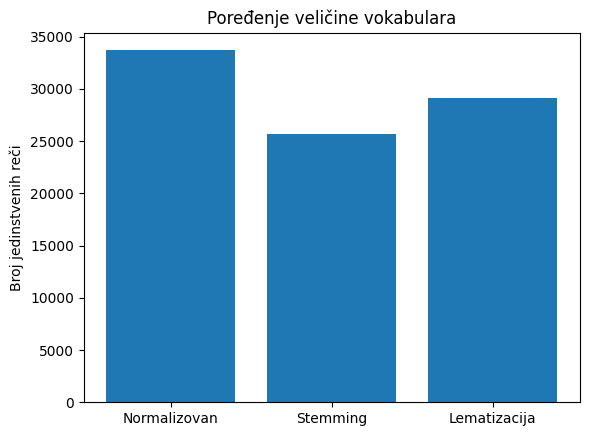

In [157]:
sizes = [
    vocab_size(df["text_normalized"]),
    vocab_size(df["text_stemmed"]),
    vocab_size(df["text_lemmatized"])
]

labels = ["Normalizovan", "Stemming", "Lematizacija"]

plt.bar(labels, sizes)
plt.title("Poređenje veličine vokabulara")
plt.ylabel("Broj jedinstvenih reči")
plt.show()

Analiza najčešćih reči pre/posle:

In [158]:
from collections import Counter

def top_words(texts, n=10):
    all_words = " ".join(texts).split()
    return Counter(all_words).most_common(n)

print("Normalizovan:", top_words(df["text_normalized"]))
print("Stemmed:", top_words(df["text_stemmed"]))
print("Lemmatized:", top_words(df["text_lemmatized"]))

Normalizovan: [('<number>', 89687), ('the', 50110), ('to', 41736), ('and', 27478), ('of', 23757), ('>', 22252), ('a', 19950), ('you', 19154), ('in', 17982), ('i', 17426)]
Stemmed: [('the', 50110), ('to', 41755), ('and', 27480), ('of', 23758), ('a', 19950), ('you', 19154), ('in', 17996), ('i', 17433), ('for', 16696), ('enron', 13388)]
Lemmatized: [('number', 90866), ('the', 50110), ('to', 41737), ('be', 38455), ('and', 27479), ('of', 23757), ('I', 21769), ('a', 19950), ('you', 19167), ('in', 17995)]


Procenat redukcije vokabulara:

In [159]:
original = vocab_size(df["text_normalized"])
stemmed = vocab_size(df["text_stemmed"])
lemmatized = vocab_size(df["text_lemmatized"])

print(f"Stemming redukcija:     {(1 - stemmed/original)*100:.1f}%")
print(f"Lematizacija redukcija: {(1 - lemmatized/original)*100:.1f}%")

Stemming redukcija:     23.7%
Lematizacija redukcija: 13.5%


Primer transformacije na konkretnom emailu:

In [160]:
idx = 0
print("Original:     ", df["text_normalized"].iloc[idx])
print("Stemmed:      ", df["text_stemmed"].iloc[idx])
print("Lemmatized:   ", df["text_lemmatized"].iloc[idx])

Original:      subject naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwhelminq but a good catchy logo stylish statlonery and outstanding website will make the task much easier we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader it isguite ciear that without good products effective business organization and practicable aim it will be hotat nowadays market but we do promise that your marketing efforts will become much more effective here is the list of clear benefits creativeness hand made original logos specially done to reflect your distinctive company image convenience logo and stationery are provided in all formats easy to use content management system letsyou change your website content and even its structure promptness you will see logo drafts within three business days affordability your marketing break through shouldn t make gaps in y

### Uklanjanje stop-reči

Stop reči su vrlo česte reči koje nemaju veliku semantičku vrednost za klasifikaciju, npr: the, is, at, on, and, of, to, in...
Kod spam klasifikacije često uklanjamo ove reči jer:
- Smanjuju dimenzionalnost
- Ne doprinose razlikovanju spam/ham
- Povećavaju šum u modelu

In [161]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords_fast(text):
    tokens = text.split()
    return " ".join([t for t in tokens 
                     if t not in ENGLISH_STOP_WORDS and t.isalpha()])

df["text_no_stop"] = df["text_normalized"].apply(remove_stopwords_fast)

In [162]:
print("Normalizovan:", vocab_size(df["text_normalized"]))
print("Bez stop reči:", vocab_size(df["text_no_stop"]))

Normalizovan: 33688
Bez stop reči: 33381


In [163]:
df["len_before"] = df["text_normalized"].apply(lambda x: len(x.split()))
df["len_after"] = df["text_no_stop"].apply(lambda x: len(x.split()))

print("Prosečna dužina pre:", df["len_before"].mean())
print("Prosečna dužina posle:", df["len_after"].mean())

Prosečna dužina pre: 250.38180865921788
Prosečna dužina posle: 130.53561452513966


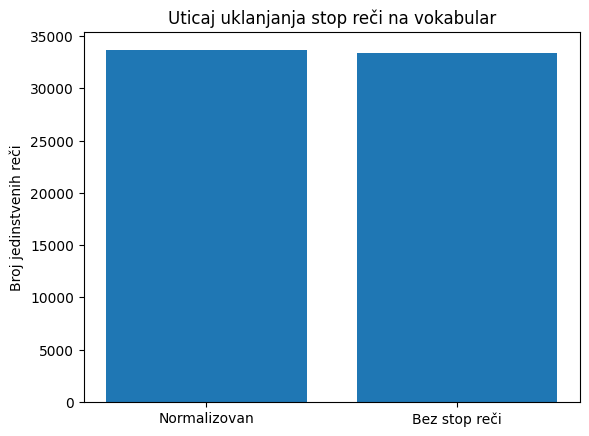

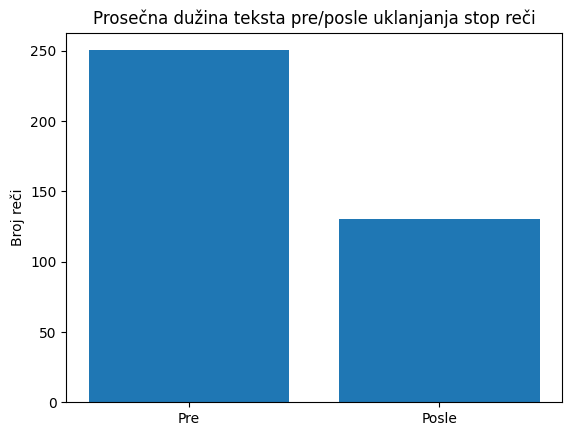

In [164]:
# Bar chart poređenja vokabulara
plt.bar(["Normalizovan", "Bez stop reči"], 
        [vocab_size(df["text_normalized"]), vocab_size(df["text_no_stop"])])
plt.title("Uticaj uklanjanja stop reči na vokabular")
plt.ylabel("Broj jedinstvenih reči")
plt.show()

# Prosečna dužina teksta
plt.bar(["Pre", "Posle"], [df["len_before"].mean(), df["len_after"].mean()])
plt.title("Prosečna dužina teksta pre/posle uklanjanja stop reči")
plt.ylabel("Broj reči")
plt.show()

In [165]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), min_df=5)
X_bigram = bigram_vectorizer.fit_transform(df["text_normalized"])

print("Broj bigrama:", len(bigram_vectorizer.vocabulary_))

Broj bigrama: 36826


### Evolucija reprezentacionog prostora

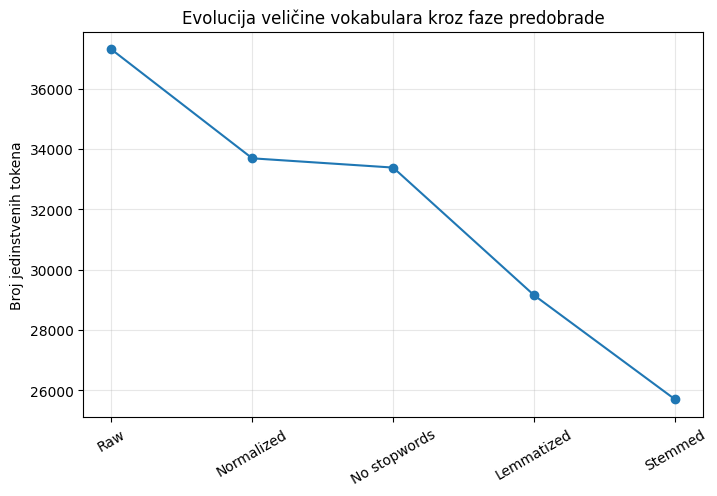

In [166]:
stages = {
    "Raw": vocab_size(df["text"]),
    "Normalized": vocab_size(df["text_normalized"]),
    "No stopwords": vocab_size(df["text_no_stop"]),
    "Lemmatized": vocab_size(df["text_lemmatized"]),
    "Stemmed": vocab_size(df["text_stemmed"]),
}

plt.figure(figsize=(8,5))
plt.plot(list(stages.keys()), list(stages.values()), marker="o")
plt.title("Evolucija veličine vokabulara kroz faze predobrade")
plt.ylabel("Broj jedinstvenih tokena")
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.show()

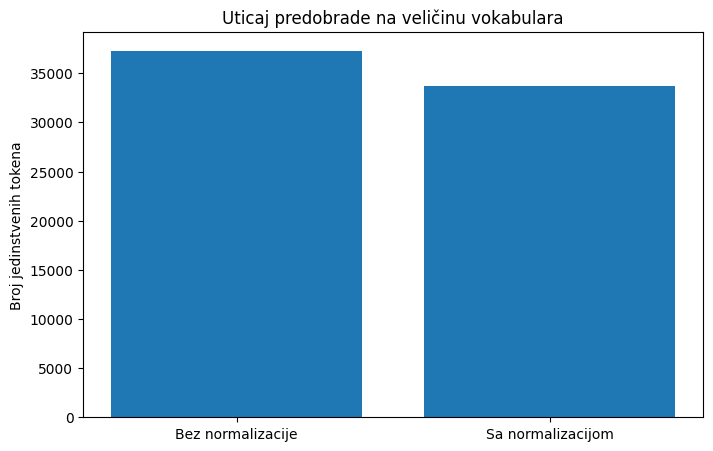

In [167]:
plt.figure(figsize=(8,5))

plt.bar(vocab_sizes.keys(), vocab_sizes.values())

plt.title("Uticaj predobrade na veličinu vokabulara")
plt.ylabel("Broj jedinstvenih tokena")

plt.show()

### Redukcija retkih termina

In [168]:
vectorizer_filtered = CountVectorizer(min_df=5)
X_filtered = vectorizer_filtered.fit_transform(df["text_normalized"])

print("Vokabular posle filtriranja retkih reči:",
      len(vectorizer_filtered.vocabulary_))

Vokabular posle filtriranja retkih reči: 9724


In [169]:
def preprocess_pipeline(text,
                         stemming=False,
                         lemmatization=False,
                         remove_stops=True):
  
    # Normalizacija
    text = normalize_text(text)
    
    # Morfološka normalizacija
    if stemming:
        text = apply_stemming(text)
    elif lemmatization:
        text = apply_lemmatization(text)
    
    # Uklanjanje stop-reci
    if remove_stops:
        text = remove_stopwords_fast(text)
    
    return text

# Priprema razlicite verzije dataseta

df['text_raw'] = df['text']  # Originalni tekst
df['text_norm'] = df['text'].apply(lambda x: preprocess_pipeline(x, False, False, False))
df['text_nostop'] = df['text'].apply(lambda x: preprocess_pipeline(x, False, False, True))
df['text_stem'] = df['text'].apply(lambda x: preprocess_pipeline(x, True, False, True))
df['text_lemma'] = df['text'].apply(lambda x: preprocess_pipeline(x, False, True, True))


print('  text_raw    - originalni tekst')
print('  text_norm   - normalizovani tekst (bez stop-reči uklanjanja)')
print('  text_nostop - normalizovani tekst bez stop-reči')
print('  text_stem   - stemming + bez stop-reči')
print('  text_lemma  - lematizacija + bez stop-reči')

  text_raw    - originalni tekst
  text_norm   - normalizovani tekst (bez stop-reči uklanjanja)
  text_nostop - normalizovani tekst bez stop-reči
  text_stem   - stemming + bez stop-reči
  text_lemma  - lematizacija + bez stop-reči


### Data Augmentation

In [170]:
import numpy as np
from nltk.corpus import wordnet

In [171]:
def get_synonyms(word):

    synonyms = set()

    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():

            synonym = lemma.name().replace("_", " ").lower()

            if synonym != word:
                synonyms.add(synonym)

    return list(synonyms)

#### Synonym Replacement

In [172]:
def eda_synonym_replacement(text, n=2):

    words = text.split()

    new_words = words.copy()

    random_words = list(set([word for word in words if get_synonyms(word)]))

    if len(random_words) == 0:
        return text

    random_words = np.random.choice(
        random_words,
        min(n, len(random_words)),
        replace=False
    )

    for word in random_words:

        synonyms = get_synonyms(word)

        if len(synonyms) > 0:

            synonym = np.random.choice(synonyms)

            new_words = [
                synonym if w == word else w
                for w in new_words
            ]

    return " ".join(new_words)

#### Random Deletion

In [173]:
def eda_random_deletion(text, p=0.1):

    words = text.split()

    if len(words) <= 5:
        return text

    new_words = [w for w in words if np.random.random() > p]

    if len(new_words) == 0:
        return words[np.random.randint(0, len(words))]

    return " ".join(new_words)

#### Random Swap

In [174]:
def eda_random_swap(text, n=2):

    words = text.split()

    if len(words) < 4:
        return text

    new_words = words.copy()

    for _ in range(n):

        idx1, idx2 = np.random.choice(len(words), 2, replace=False)

        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]

    return " ".join(new_words)

In [175]:
def apply_eda(text):

    r = np.random.random()

    if r < 0.33:
        return eda_synonym_replacement(text)

    elif r < 0.66:
        return eda_random_deletion(text)

    else:
        return eda_random_swap(text)

In [176]:
demo = "get a free offer now click here for the best price"

print("Original:")
print(demo)

print("\nSynonym replacement:")
print(eda_synonym_replacement(demo))

print("\nRandom deletion:")
print(eda_random_deletion(demo))

print("\nRandom swap:")
print(eda_random_swap(demo))

Original:
get a free offer now click here for the best price

Synonym replacement:
get type a free offer like a shot click here for the best price

Random deletion:
get a free offer now click here the price

Random swap:
get a price offer the click here for now best free


In [177]:
# Augmentacija manjinske klase (spam)
# Cilj: smanjiti klasnu neravnotežu

spam_df = df[df['spam'] == 1].copy()
ham_df = df[df['spam'] == 0].copy()

print("Pre augmentacije:")
print(f"  Ham:  {len(ham_df)} emailova")
print(f"  Spam: {len(spam_df)} emailova")
print(f"  Odnos: {len(ham_df)/len(spam_df):.2f}:1")

# Ciljni broj spam emailova
target_spam = 2000

current_spam = len(spam_df)
to_generate = max(0, target_spam - current_spam)

spam_texts_list = spam_df['text_nostop'].tolist()

augmented_texts = []
augmented_labels = []

methods = ['synonym', 'deletion', 'swap']

for i in range(to_generate):

    base_text = np.random.choice(spam_texts_list)

    method = np.random.choice(methods)

    if method == 'synonym':
        aug_text = eda_synonym_replacement(base_text, n=3)

    elif method == 'deletion':
        aug_text = eda_random_deletion(base_text, p=0.1)

    else:
        aug_text = eda_random_swap(base_text, n=2)

    augmented_texts.append(aug_text)
    augmented_labels.append(1)

aug_df = pd.DataFrame({
    'text_nostop': augmented_texts,
    'spam': augmented_labels
})

df_augmented = pd.concat(
    [df[['text_nostop','spam']], aug_df],
    ignore_index=True
)

print("\nPosle augmentacije:")
print(f"  Ham:  {len(df_augmented[df_augmented['spam']==0])} emailova")
print(f"  Spam: {len(df_augmented[df_augmented['spam']==1])} emailova")
print(f"  Odnos: {len(df_augmented[df_augmented['spam']==0]) / len(df_augmented[df_augmented['spam']==1]):.2f}:1")

Pre augmentacije:
  Ham:  4360 emailova
  Spam: 1368 emailova
  Odnos: 3.19:1



Posle augmentacije:
  Ham:  4360 emailova
  Spam: 2000 emailova
  Odnos: 2.18:1


In [178]:
df_augmented.sample(5)

,text_nostop,spam
267,subject localized software languages available hello like offer localized software versions german french spanish uk ali iisted software avaiiabie immediate download need wait week cd delivery jus...,1
1321,subject visual identity logo working company s image start visual identity key good impression help ll buildinq positive visuai imaqe company creatinq outstanding ioqo presentable stationery items...,1
3675,subject draft editor questions ll vince attached editor s latest edits draft couple things d like discuss right lunch john martin doc john d martin carr p collins chair finance finance department ...,0
860,subject perfect visual solution business working company s image start visual identity key good impression help ll buiiding positive visual imaqe company creatinq outstandinq logo presentabie stat...,1
407,subject failure notice hi qmail send program mail bmadesign com m afraid wasn t able deliver message following addresses permanent error ve given sorry didn t work sorry mailbox vpopmail line copy...,1


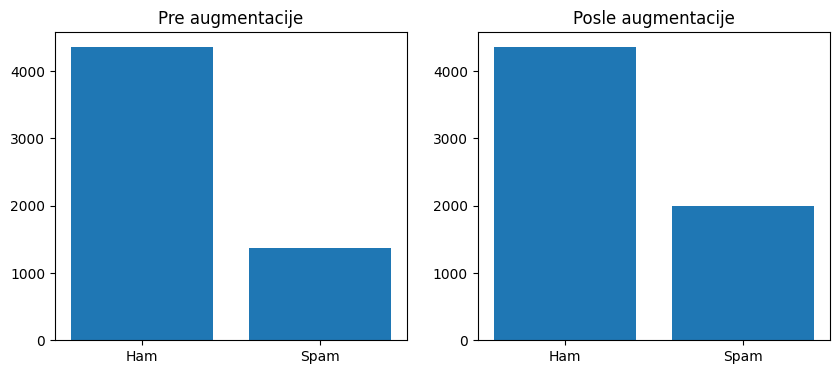

In [179]:
before = [4360, 1368]
after = [4360, 2000]

labels = ['Ham', 'Spam']

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].bar(labels, before)
ax[0].set_title("Pre augmentacije")

ax[1].bar(labels, after)
ax[1].set_title("Posle augmentacije")

plt.show()

# 4. Reprezentacija teksta i uticaj predobrade

### Bag-of-Words i TF-IDF reprezentacija

In [180]:
from sklearn.model_selection import train_test_split

# Tekst i labela
X = df['text_nostop']
y = df['spam']

# Stratified split - čuva odnos spam/ham
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=== Train / Test split ===")
print(f"Ukupan dataset: {len(X)} emailova")

print(f"\nTrening skup: {len(X_train)}")
print(f"Test skup: {len(X_test)}")

print(f"\nSpam u treningu: {y_train.mean()*100:.2f}%")
print(f"Spam u testu: {y_test.mean()*100:.2f}%")

=== Train / Test split ===
Ukupan dataset: 5728 emailova

Trening skup: 4582
Test skup: 1146

Spam u treningu: 23.88%
Spam u testu: 23.91%


Dataset je podeljen na trening i test skup u odnosu 80:20.
Prilikom podele korišćena je stratifikacija po klasi (stratify=y), čime je očuvana originalna distribucija spam i ham poruka u oba skupa. Ovaj pristup sprečava pojavu pristrasnosti tokom evaluacije modela.

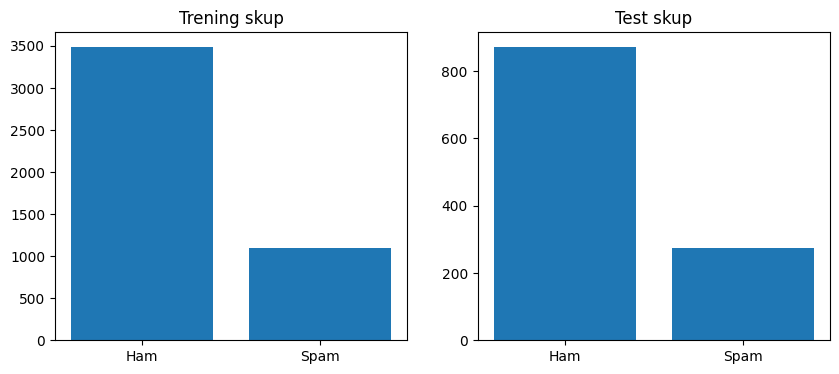

In [181]:
labels = ['Ham', 'Spam']

train_counts = [
    (y_train == 0).sum(),
    (y_train == 1).sum()
]

test_counts = [
    (y_test == 0).sum(),
    (y_test == 1).sum()
]

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].bar(labels, train_counts)
ax[0].set_title("Trening skup")

ax[1].bar(labels, test_counts)
ax[1].set_title("Test skup")

plt.show()

In [182]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_full = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf_full.fit_transform(X_train)
X_test_tfidf = tfidf_full.transform(X_test)

print("TF-IDF shape:")
print("Train:", X_train_tfidf.shape)
print("Test :", X_test_tfidf.shape)

TF-IDF shape:
Train: (4582, 5000)
Test : (1146, 5000)


TF-IDF vektorizacija transformiše tekstualne dokumente u numeričke vektore koji predstavljaju važnost pojedinačnih termina u dokumentu u odnosu na ceo korpus. U ovom radu korišćen je vokabular od 5000 najčešćih karakteristika.

In [183]:
density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])

print("\n=== TF-IDF matrica ===")
print("Shape:", X_train_tfidf.shape)
print("Gustina matrice:", round(density,6))
print("Sparsity:", round(1-density,6))


=== TF-IDF matrica ===
Shape: (4582, 5000)
Gustina matrice: 0.015482
Sparsity: 0.984518


In [184]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=1000)

X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)

print("\nNakon selekcije karakteristika:")
print("Train:", X_train_selected.shape)
print("Test :", X_test_selected.shape)


Nakon selekcije karakteristika:
Train: (4582, 1000)
Test : (1146, 1000)


In [185]:
print("\n=== Redukcija dimenzije ===")

print("Pre selekcije:", X_train_tfidf.shape[1])
print("Posle selekcije:", X_train_selected.shape[1])


=== Redukcija dimenzije ===
Pre selekcije: 5000
Posle selekcije: 1000


Chi-square test je korišćen za selekciju najinformativnijih karakteristika.
Ova metoda meri statističku zavisnost između pojavljivanja reči i klase dokumenta (spam ili ham). Veće χ² vrednosti ukazuju na veću diskriminativnu moć karakteristike.

In [186]:
feature_names = tfidf_full.get_feature_names_out()

scores = np.nan_to_num(selector.scores_)

chi_df = pd.DataFrame({
    "feature": feature_names,
    "chi2_score": scores
})

chi_df = chi_df.sort_values("chi2_score", ascending=False)

In [187]:
top_features = chi_df.head(20)

print('\nTop 20 karakteristika po Chi-square testu:')
print(f'{"Karakteristika":<25} {"Chi² vrednost":<15}')
print('-'*40)

for _, row in top_features.iterrows():
    print(f'{row["feature"]:<25} {row["chi2_score"]:.2f}')


Top 20 karakteristika po Chi-square testu:
Karakteristika            Chi² vrednost  
----------------------------------------
save                      79.08
click                     71.38
money                     70.98
viagra                    67.14
software                  66.20
ect                       65.86
enron                     62.04
adobe                     57.03
vince                     53.61
logo                      53.47
website                   51.49
life                      50.10
online                    50.03
andmanyother              46.24
stationery                38.27
man                       37.51
worldwide                 34.38
account                   33.72
hou                       33.22
sex                       33.07


Rezultati Chi-square testa pokazuju da su reči poput “click”, “money”, “viagra”, “software” i “save” među najinformativnijim za identifikaciju spam poruka. Ove reči su tipične za promotivne ili prevarne email kampanje.

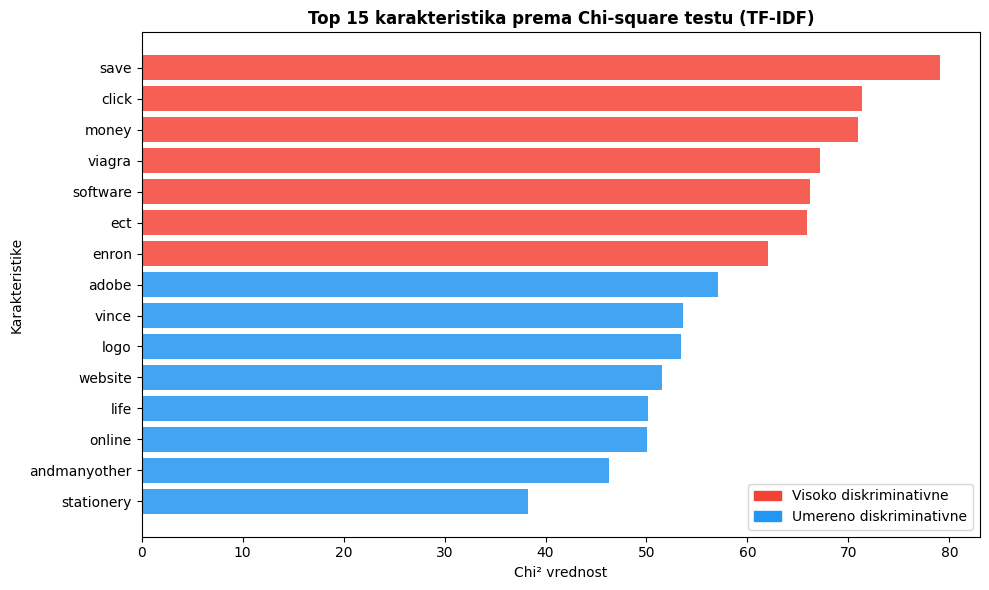

In [188]:
import matplotlib.patches as mpatches

top_df = chi_df.head(15).sort_values("chi2_score")

fig, ax = plt.subplots(figsize=(10,6))

colors = [
    "#F44336" if score > top_df["chi2_score"].median()
    else "#2196F3"
    for score in top_df["chi2_score"]
]

ax.barh(
    top_df["feature"],
    top_df["chi2_score"],
    color=colors,
    alpha=0.85
)

ax.set_title(
    "Top 15 karakteristika prema Chi-square testu (TF-IDF)",
    fontweight="bold"
)

ax.set_xlabel("Chi² vrednost")
ax.set_ylabel("Karakteristike")

red_patch = mpatches.Patch(
    color="#F44336",
    label="Visoko diskriminativne"
)

blue_patch = mpatches.Patch(
    color="#2196F3",
    label="Umereno diskriminativne"
)

ax.legend(handles=[red_patch, blue_patch])

plt.tight_layout()

plt.savefig(
    "fig10_chi2_features.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [189]:
print("\nNajinformativnije reči za klasifikaciju spam poruka:")

for word in chi_df.head(10)["feature"]:
    print("-", word)


Najinformativnije reči za klasifikaciju spam poruka:
- save
- click
- money
- viagra
- software
- ect
- enron
- adobe
- vince
- logo


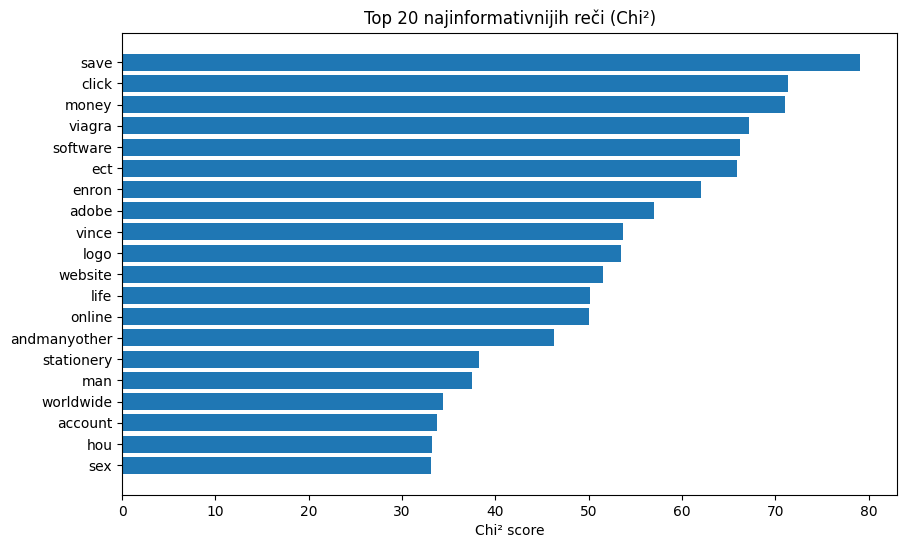

In [190]:
chi_df = pd.DataFrame({
    "feature": feature_names,
    "chi2_score": scores
})

chi_df = chi_df.sort_values("chi2_score", ascending=False)

top20 = chi_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top20["feature"], top20["chi2_score"])
plt.gca().invert_yaxis()

plt.title("Top 20 najinformativnijih reči (Chi²)")
plt.xlabel("Chi² score")
plt.show()

### TF-IDF + LSA

LSA shape: (4582, 100)
Objašnjena varijansa sa 100 komponenti: 31.76%


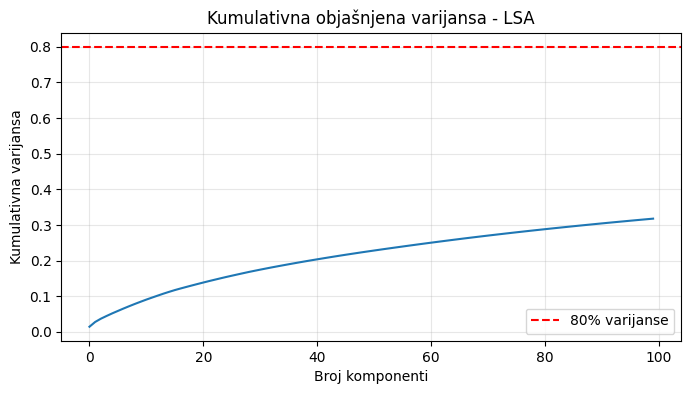

In [191]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

lsa_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)),
    ('svd',   TruncatedSVD(n_components=100, random_state=42))
])

X_train_lsa = lsa_pipe.fit_transform(X_train, y_train)
X_test_lsa  = lsa_pipe.transform(X_test)

print(f"LSA shape: {X_train_lsa.shape}")
explained = lsa_pipe['svd'].explained_variance_ratio_.sum()
print(f"Objašnjena varijansa sa 100 komponenti: {explained:.2%}")

plt.figure(figsize=(8,4))
cumvar = np.cumsum(lsa_pipe['svd'].explained_variance_ratio_)
plt.plot(cumvar)
plt.axhline(y=0.8, color='r', linestyle='--', label='80% varijanse')
plt.title("Kumulativna objašnjena varijansa - LSA")
plt.xlabel("Broj komponenti")
plt.ylabel("Kumulativna varijansa")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

,config,vocab,sparsity
0,"min=1, max=1.0",33381,0.997574
1,"min=2, max=1.0",18216,0.995700
2,"min=5, max=1.0",9434,0.992125
3,"min=5, max=0.9",9433,0.992230
4,"min=5, max=0.7",9433,0.992230


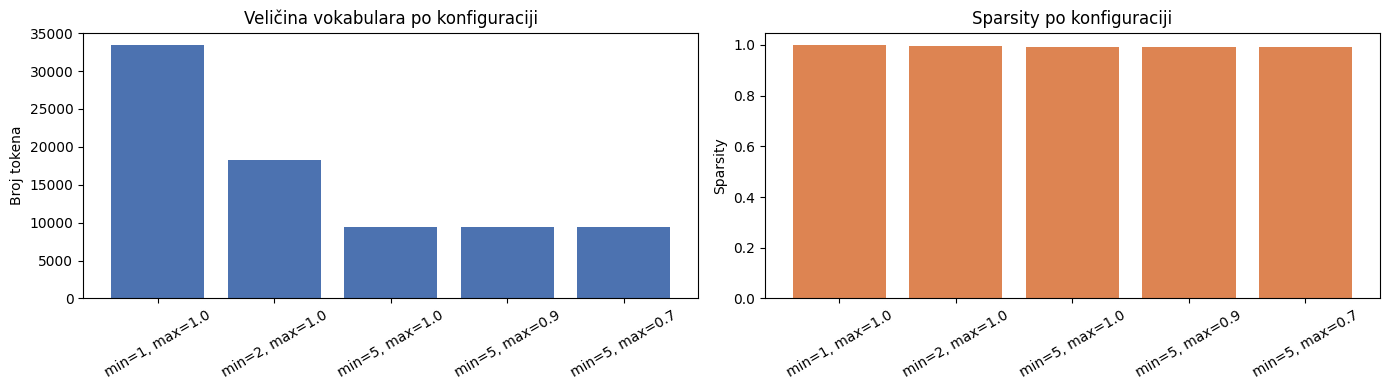

In [192]:
configs = [
    {'min_df': 1,  'max_df': 1.0},
    {'min_df': 2,  'max_df': 1.0},
    {'min_df': 5,  'max_df': 1.0},
    {'min_df': 5,  'max_df': 0.9},
    {'min_df': 5,  'max_df': 0.7},
]

results = []
for cfg in configs:
    vec = TfidfVectorizer(max_features=None, **cfg)
    X = vec.fit_transform(df['text_nostop'])
    results.append({
        'config':    f"min={cfg['min_df']}, max={cfg['max_df']}",
        'vocab':     X.shape[1],
        'sparsity':  1 - X.nnz / (X.shape[0] * X.shape[1])
    })

results_df = pd.DataFrame(results)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(results_df['config'], results_df['vocab'], color='#4C72B0')
axes[0].set_title("Veličina vokabulara po konfiguraciji")
axes[0].set_ylabel("Broj tokena")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(results_df['config'], results_df['sparsity'], color='#DD8452')
axes[1].set_title("Sparsity po konfiguraciji")
axes[1].set_ylabel("Sparsity")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

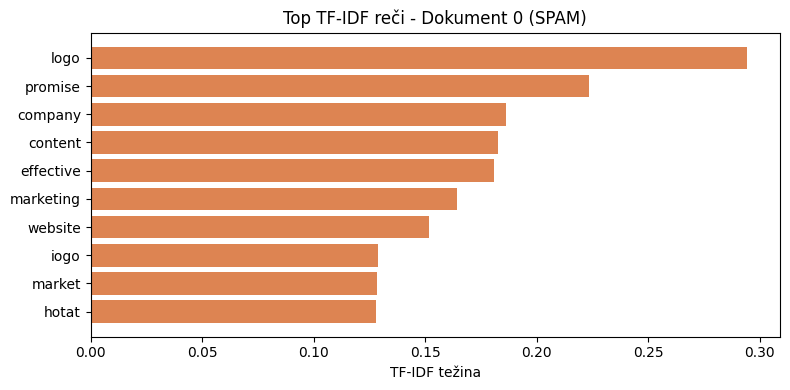

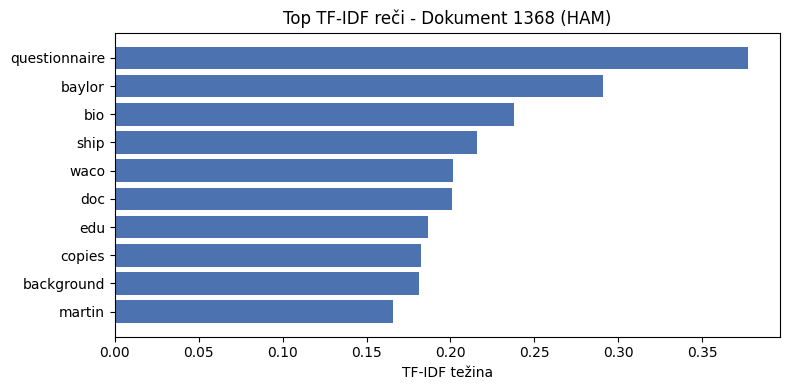

In [193]:
tfidf_viz = TfidfVectorizer(max_features=5000, min_df=2)
X_tfidf_viz = tfidf_viz.fit_transform(df['text_nostop'])
feature_names = tfidf_viz.get_feature_names_out()

def show_top_tfidf(doc_idx, top_n=10):
    row = X_tfidf_viz[doc_idx]
    scores = zip(row.indices, row.data)
    top = sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]
    words  = [feature_names[i] for i, s in top]
    values = [s for i, s in top]
    label  = "SPAM" if df['spam'].iloc[doc_idx] == 1 else "HAM"
    
    plt.figure(figsize=(8, 4))
    plt.barh(words, values, color='#DD8452' if label=='SPAM' else '#4C72B0')
    plt.title(f"Top TF-IDF reči - Dokument {doc_idx} ({label})")
    plt.xlabel("TF-IDF težina")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Prikaži jedan spam i jedan ham primer
spam_idx = df[df['spam']==1].index[0]
ham_idx  = df[df['spam']==0].index[0]

show_top_tfidf(spam_idx)
show_top_tfidf(ham_idx)


### BoW reprezentacija + Sparsity

Bag-of-Words (BoW) predstavlja najjednostavniju reprezentaciju teksta, svaki dokument se opisuje vektorom frekvencija reči, pri čemu se gubi informacija o redosledu. Rezultujuća matrica je izrazito retka (sparse), što direktno odražava kvalitet i raznovrsnost korpusa.

BoW matrica shape: (4582, 5000)
Sparsity: 98.6395%


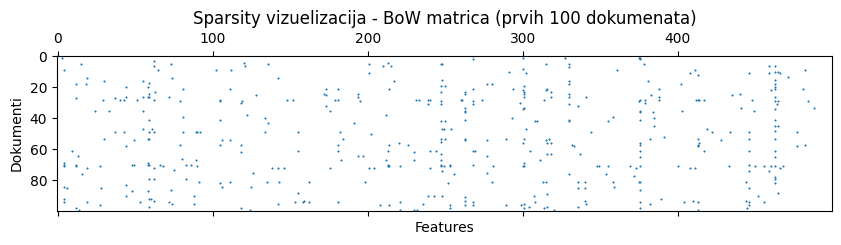

In [194]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vec = CountVectorizer(max_features=5000)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

sparsity = 1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])
print(f"BoW matrica shape: {X_train_bow.shape}")
print(f"Sparsity: {sparsity:.4%}")

plt.figure(figsize=(10,4))
plt.spy(X_train_bow[:100, :500], markersize=0.5)
plt.title("Sparsity vizuelizacija - BoW matrica (prvih 100 dokumenata)")
plt.xlabel("Features")
plt.ylabel("Dokumenti")
plt.show()

Unigram (1,1): vocab=5,000, sparsity=98.6399%
Bigram (1,2): vocab=5,000, sparsity=98.4561%
Trigram (1,3): vocab=5,000, sparsity=98.3753%


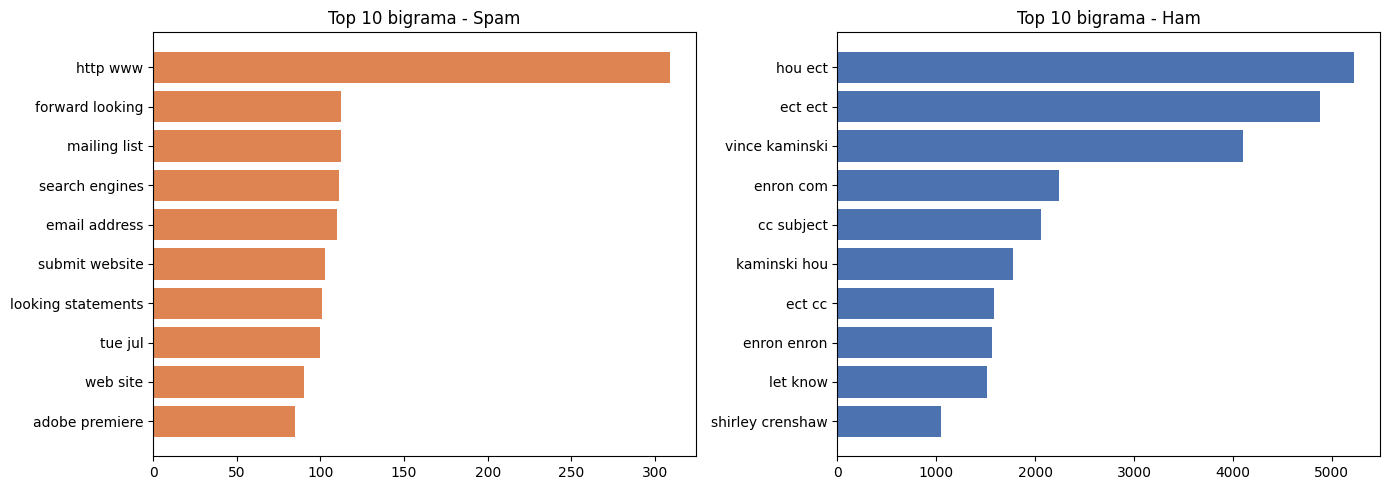

In [195]:
ngram_configs = {
    'Unigram (1,1)':    (1,1),
    'Bigram (1,2)':     (1,2),
    'Trigram (1,3)':    (1,3),
}

ngram_results = {}

for name, ngram_range in ngram_configs.items():
    vec = CountVectorizer(max_features=5000, ngram_range=ngram_range)
    X = vec.fit_transform(df['text_nostop'])
    sparsity = 1 - X.nnz / (X.shape[0] * X.shape[1])
    ngram_results[name] = {
        'vocab_size': len(vec.vocabulary_),
        'sparsity': sparsity
    }
    print(f"{name}: vocab={len(vec.vocabulary_):,}, sparsity={sparsity:.4%}")

# Top bigrami za spam vs ham
vec_bi_spam = CountVectorizer(ngram_range=(2,2), max_features=20)
vec_bi_ham  = CountVectorizer(ngram_range=(2,2), max_features=20)

spam_texts = df[df['spam']==1]['text_nostop']
ham_texts  = df[df['spam']==0]['text_nostop']

X_bi_spam = vec_bi_spam.fit_transform(spam_texts)
X_bi_ham  = vec_bi_ham.fit_transform(ham_texts)

top_spam_bigrams = pd.DataFrame({
    'bigram': vec_bi_spam.get_feature_names_out(),
    'freq':   X_bi_spam.sum(axis=0).A1
}).sort_values('freq', ascending=False).head(10)

top_ham_bigrams = pd.DataFrame({
    'bigram': vec_bi_ham.get_feature_names_out(),
    'freq':   X_bi_ham.sum(axis=0).A1
}).sort_values('freq', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_spam_bigrams['bigram'], top_spam_bigrams['freq'], color='#DD8452')
axes[0].set_title("Top 10 bigrama - Spam")
axes[0].invert_yaxis()

axes[1].barh(top_ham_bigrams['bigram'], top_ham_bigrams['freq'], color='#4C72B0')
axes[1].set_title("Top 10 bigrama - Ham")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Word2Vec 

Word2Vec trenira plitku neuralnu mrežu na lokalnom kontekstu reči i generiše dense vektore koji kodiraju semantičke odnose između reči. Postoje dva arhitekturna pristupa: `CBOW`(predviđanje reči iz konteksta) i `Skip-gram` (predviđanje konteksta iz reči). 

Dokument se reprezentuje usrednjavanjem vektora svih njegovih reči (mean pooling). Glavni nedostatak je nemogućnost reprezentacije reči koje nisu viđene tokom treninga (OOV problem), što je posebno relevantno za spam email gde se česte reči namerno deformišu radi zaobilaženja filtera (npr. v1agra, fr3e).

In [196]:
from gensim.models import Word2Vec

sentences = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences, 
    vector_size=100, 
    window=5, 
    min_count=2, 
    workers=4, 
    seed=42
)

def doc_to_w2v(text, model, dim=100):
    tokens = text.split()
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X_train_w2v = np.array([doc_to_w2v(t, w2v_model) for t in X_train])
X_test_w2v  = np.array([doc_to_w2v(t, w2v_model) for t in X_test])
print(f"Word2Vec shape: {X_train_w2v.shape}")

Word2Vec shape: (4582, 100)


In [197]:
all_tokens = set(" ".join(X_train).split())
oov_tokens = [t for t in all_tokens if t not in w2v_model.wv]

print(f"Ukupno jedinstvenih tokena: {len(all_tokens):,}")
print(f"OOV tokeni: {len(oov_tokens):,} ({len(oov_tokens)/len(all_tokens):.2%})")

# Primeri OOV tokena - relevantni za spam
print("\nPrimeri OOV tokena:")
print(oov_tokens[:20])

Ukupno jedinstvenih tokena: 30,206
OOV tokeni: 12,414 (41.10%)

Primeri OOV tokena:
['pitching', 'gbmdc', 'extroversion', 'wkshp', 'lacking', 'emailings', 'brcm', 'discipine', 'dhy', 'inspector', 'arefieva', 'chcialbym', 'adjourns', 'finalised', 'dialect', 'gory', 'seshadhri', 'telemetry', 'jadzi', 'benedictinen']


In [198]:
# Provera semantičkih odnosa naučenih iz spam korpusa
test_words = ['money', 'free', 'click', 'email', 'enron']

for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' -> najbliže reči:")
        for w, score in similar:
            print(f"  {w:<20} {score:.3f}")


'money' -> najbliže reči:
  guaranteed           0.938
  earn                 0.931
  pay                  0.916
  amonqthe             0.913
  lose                 0.908

'free' -> najbliže reči:
  activate             0.847
  simply               0.840
  classified           0.840
  ads                  0.834
  check                0.827

'click' -> najbliže reči:
  clicking             0.955
  link                 0.954
  mailings             0.953
  opt                  0.936
  unsubscribe          0.936

'email' -> najbliže reči:
  address              0.916
  reply                0.901
  receiving            0.885
  messages             0.871
  corpjobsl            0.862

'enron' -> najbliže reči:
  casari               0.800
  srivastav            0.794
  parkhill             0.788
  werner               0.781
  alhamd               0.780


### FastText

FastText proširuje Word2Vec uvođenjem subword informacija — svaka reč se razlaže na n-grame karaktera, čime model može da generiše vektore čak i za reči koje nisu viđene tokom treninga. 

Ovo je posebno važno u kontekstu spam emailova gde se česte reči poput "viagra" ili "free" namerno pišu sa greškama (v1agra, fr3e) kako bi zaobišle filtre. FastText time postiže 100% pokrivenost vokabulara, što ga čini robustnijim od Word2Vec i GloVe u ovom domenu

In [199]:
from gensim.models import FastText

ft_model = FastText(
    sentences, 
    vector_size=100, 
    window=5, 
    min_count=2, 
    workers=4, 
    seed=42
)

def doc_to_ft(text, model, dim=100):
    tokens = text.split()
    vecs = [model.wv[t] for t in tokens]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X_train_ft = np.array([doc_to_ft(t, ft_model) for t in X_train])
X_test_ft  = np.array([doc_to_ft(t, ft_model) for t in X_test])
print(f"FastText shape: {X_train_ft.shape}")

FastText shape: (4582, 100)


In [200]:
oov_spam_examples = ['v1agra', 'fr33', 'cl1ck', 'moneey', 'freee']

print("FastText OOV demonstracija - obfuskovane spam reči:\n")
for word in oov_spam_examples:
    similar = ft_model.wv.most_similar(word, topn=3)
    print(f"  '{word}' -> najbliže: {[w for w, s in similar]}")

FastText OOV demonstracija - obfuskovane spam reči:

  'v1agra' -> najbliže: ['viagra', 'upshot', 'dreamweaver']
  'fr33' -> najbliže: ['fr', 'fro', 'downtown']
  'cl1ck' -> najbliže: ['clck', 'ck', 'ciick']
  'moneey' -> najbliže: ['mone', 'shouldn', 'havemore']
  'freee' -> najbliže: ['freeze', 'freepdf', 'freebsd']


### GloVe

GloVe (Global Vectors for Word Representation) trenira se na globalnoj ko-okurencijskoj matrici celog korpusa, za razliku od Word2Vec koji koristi lokalni prozor konteksta. Pretreniran na velikim korpusima (Wikipedia, Common Crawl — 6 milijardi tokena), GloVe pruža kvalitetne generalne vektore.

Glavni nedostaci u kontekstu spam detekcije su: ne podržava OOV reči, ne može da se adaptira na domenski specifičan vokabular, i ne poznaje specifičan žargon spam emailova.

In [201]:

# ==============================
# 1. Učitavanje GloVe embeddinga
# ==============================

def load_glove_embeddings(file_path):
    embeddings = {}

    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector

    print(f"Loaded {len(embeddings):,} word vectors.")
    return embeddings


glove = load_glove_embeddings("glove.6B.100d.txt")


# =====================================
# 2. Pretvaranje dokumenta u GloVe vektor
# =====================================

def document_to_glove_vector(text, embeddings, dim=100):

    words = text.split()
    vectors = []

    for word in words:
        if word in embeddings:
            vectors.append(embeddings[word])

    if len(vectors) == 0:
        return np.zeros(dim)

    return np.mean(vectors, axis=0)


# =====================================
# 3. Pretvaranje dataset-a u GloVe
# =====================================

X_train_glove = np.array([
    document_to_glove_vector(text, glove)
    for text in X_train
])

X_test_glove = np.array([
    document_to_glove_vector(text, glove)
    for text in X_test
])


# =====================================
# 4. Provera dimenzija
# =====================================

print("Train shape:", X_train_glove.shape)
print("Test shape:", X_test_glove.shape)

Loaded 400,000 word vectors.
Train shape: (4582, 100)
Test shape: (1146, 100)


### Poređenje pokrivenosti vokabulara

Pokrivenost vokabulara direktno utiče na kvalitet reprezentacije. Modeli sa niskom pokrivenošću prisiljavaju na nulte vektore za nepoznate reči čime se gubi informacija. U spam domenu ovo je posebno izraženo zbog namerne obfuskacije teksta.

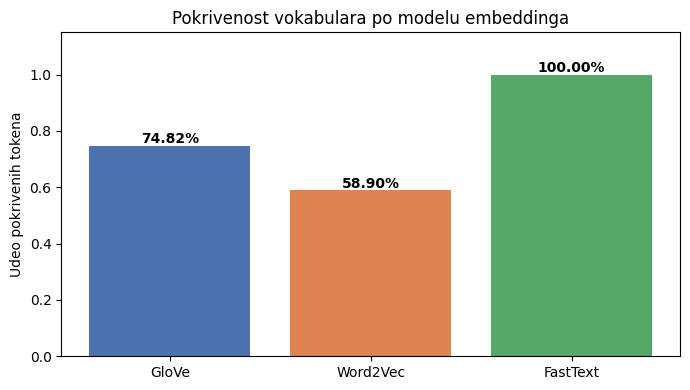

In [202]:
all_tokens = set(" ".join(X_train).split())

glove_cov = sum(1 for t in all_tokens if t in glove) / len(all_tokens)
w2v_cov   = sum(1 for t in all_tokens if t in w2v_model.wv) / len(all_tokens)
ft_cov    = 1.0

coverage_df = pd.DataFrame({
    'Model':       ['GloVe', 'Word2Vec', 'FastText'],
    'Pokrivenost': [glove_cov, w2v_cov, ft_cov]
})

plt.figure(figsize=(7,4))
bars = plt.bar(
    coverage_df['Model'], 
    coverage_df['Pokrivenost'],
    color=['#4C72B0', '#DD8452', '#55A868']
)
for bar, val in zip(bars, coverage_df['Pokrivenost']):
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 0.01,
        f"{val:.2%}", ha='center', fontweight='bold'
    )
plt.title("Pokrivenost vokabulara po modelu embeddinga")
plt.ylabel("Udeo pokrivenih tokena")
plt.ylim(0, 1.15)
plt.tight_layout()
plt.show()


###  Meta features + Feature Fusion

Pored reprezentacija zasnovanih isključivo na tekstu, moguće je ručno konstruisati karakteristike koje kodiraju strukturna i statistička svojstva emaila. Kombinovanjem TF-IDF sa meta karakteristikama (hibridna reprezentacija) spaja se leksička i strukturna informacija u jedinstven feature vektor.

Samo TF-IDF:    (4582, 5000)
TF-IDF + Meta:  (4582, 5008)


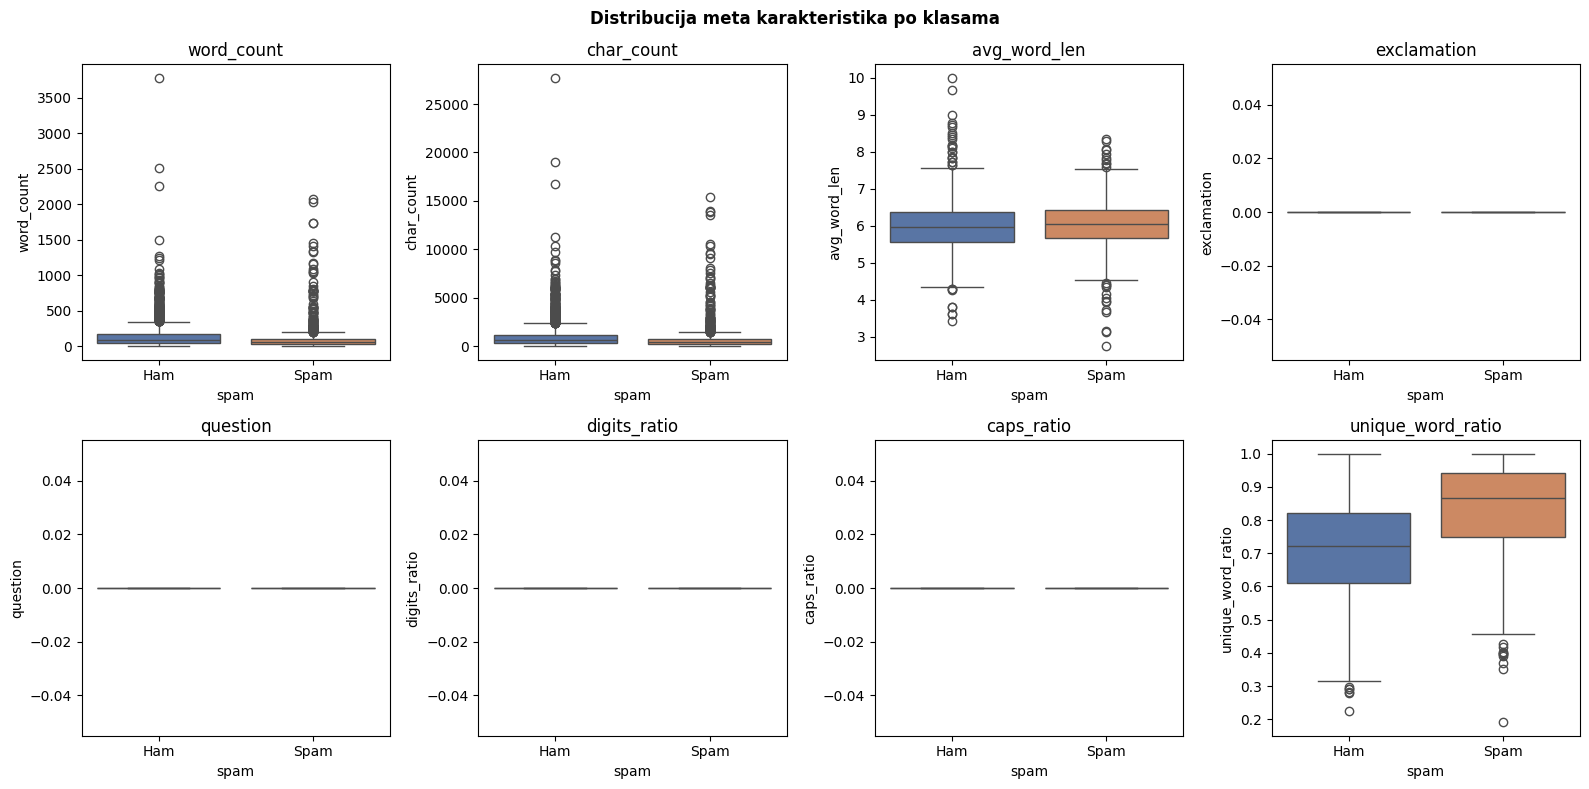

In [203]:
from scipy.sparse import hstack, csr_matrix

def extract_meta_features(text):
    return {
        'word_count':        len(text.split()),
        'char_count':        len(text),
        'avg_word_len':      np.mean([len(w) for w in text.split()]) if text.split() else 0,
        'exclamation':       text.count('!'),
        'question':          text.count('?'),
        'digits_ratio':      sum(c.isdigit() for c in text) / max(len(text), 1),
        'caps_ratio':        sum(c.isupper() for c in text) / max(len(text), 1),
        'unique_word_ratio': len(set(text.split())) / max(len(text.split()), 1)
    }

# Kreiranje meta feature-a
meta_train = pd.DataFrame([extract_meta_features(t) for t in X_train])
meta_test  = pd.DataFrame([extract_meta_features(t) for t in X_test])

# Kombinovanje sa TF-IDF
X_train_combined = hstack([X_train_tfidf, csr_matrix(meta_train.values)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(meta_test.values)])

print(f"Samo TF-IDF:    {X_train_tfidf.shape}")
print(f"TF-IDF + Meta:  {X_train_combined.shape}")

# ===============================
# Vizualizacija meta feature-a
# ===============================

meta_train['spam'] = y_train.values

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

feature_cols = [c for c in meta_train.columns if c != 'spam']

for i, col in enumerate(feature_cols):

    sns.boxplot(
        x='spam',
        y=col,
        hue='spam',          
        data=meta_train,
        palette=['#4C72B0', '#DD8452'],
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['Ham', 'Spam'])

plt.suptitle("Distribucija meta karakteristika po klasama", fontweight='bold')
plt.tight_layout()
plt.show()

### t-SNE vizuelizacija

t-SNE vizuelizacija omogućava intuitivnu procenu separabilnosti klasa u različitim reprezentacionim prostorima. Jasno razdvojena narandžasta (spam) i plava (ham) regija ukazuje na bolju linearnu separabilnost i potencijalno bolju performansu klasifikatora u tom prostoru.

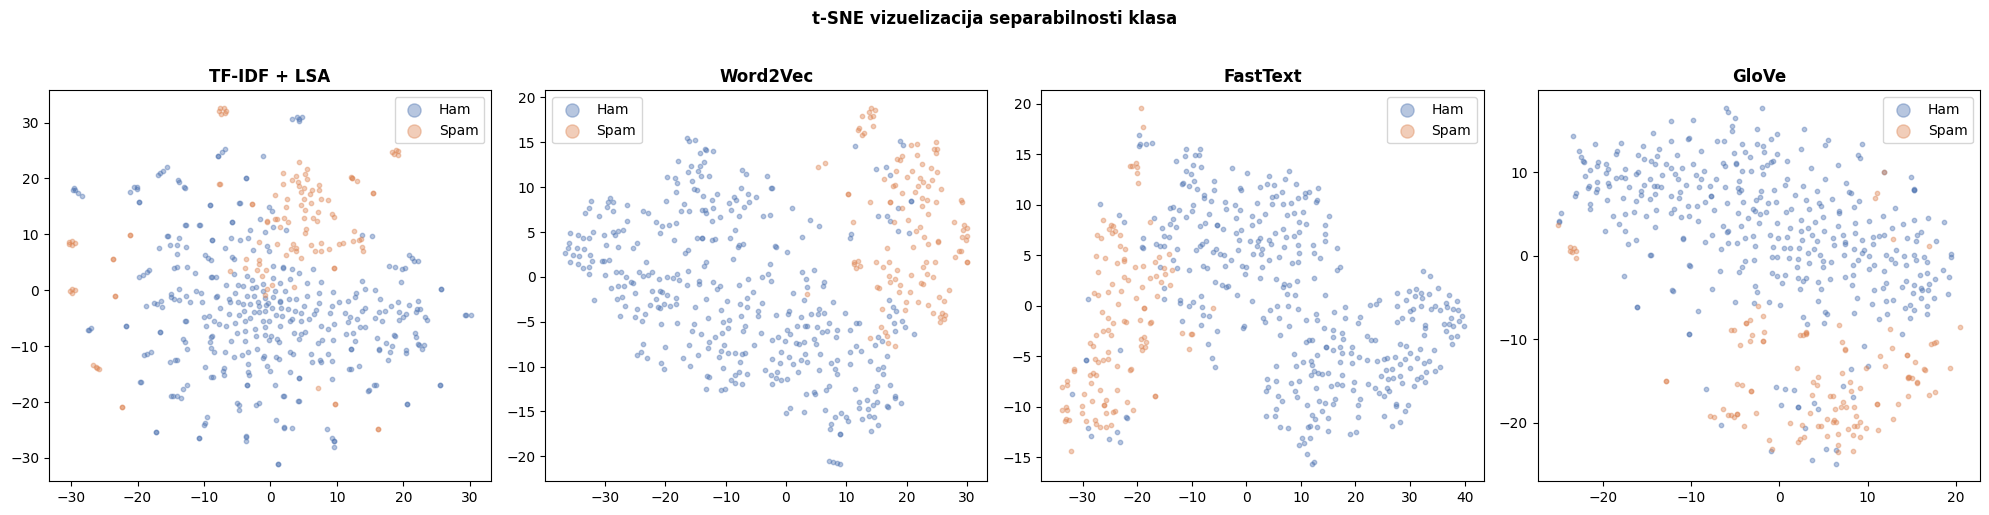

In [204]:
from sklearn.manifold import TSNE

sample_idx    = np.random.choice(len(X_train), 500, replace=False)
labels_sample = y_train.iloc[sample_idx].values

representations = [
    ("TF-IDF + LSA", X_train_lsa[sample_idx]),
    ("Word2Vec",     X_train_w2v[sample_idx]),
    ("FastText",     X_train_ft[sample_idx]),
    ("GloVe",        X_train_glove[sample_idx]),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, X_rep) in zip(axes, representations):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X_rep)
    
    ax.scatter(X_2d[labels_sample==0, 0], X_2d[labels_sample==0, 1],
               alpha=0.4, label='Ham',  c='#4C72B0', s=10)
    ax.scatter(X_2d[labels_sample==1, 0], X_2d[labels_sample==1, 1],
               alpha=0.4, label='Spam', c='#DD8452', s=10)
    ax.set_title(name, fontweight='bold')
    ax.legend(markerscale=3)

plt.suptitle("t-SNE vizuelizacija separabilnosti klasa", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 5: Klasifikacija i Evaluacija

### Baseline modeli (ML)

In [205]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_tfidf, y_train)
y_pred_dummy = dummy.predict(X_test_tfidf)

print("Baseline (majority class):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"  F1:       {f1_score(y_test, y_pred_dummy, zero_division=0):.4f}")

Baseline (majority class):
  Accuracy: 0.7609
  F1:       0.0000


### Klasični ML modeli

In [206]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, accuracy_score)

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    
    try:
        prob = model.predict_proba(X_te)[:,1]
    except:
        prob = model.decision_function(X_te)
    auc = roc_auc_score(y_te, prob)
    
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'AUC': auc, 
            'y_pred': y_pred}

ml_models = [
    ('Naive Bayes',          MultinomialNB(),          X_train_tfidf,    X_test_tfidf),
    ('Complement NB',        ComplementNB(),           X_train_tfidf,    X_test_tfidf),
    ('Logistic Regression',  LogisticRegression(max_iter=1000), X_train_tfidf, X_test_tfidf),
    ('LinearSVC',            LinearSVC(max_iter=1000), X_train_tfidf,    X_test_tfidf),
    ('Random Forest',        RandomForestClassifier(n_estimators=100, random_state=42), 
                                                       X_train_tfidf,    X_test_tfidf),
]

results = []
for name, model, X_tr, X_te in ml_models:
    res = evaluate_model(name, model, X_tr, X_te, y_train, y_test)
    results.append(res)
    print(f"{name:<25} Acc={res['Accuracy']:.4f}  F1={res['F1']:.4f}  AUC={res['AUC']:.4f}")

Naive Bayes               Acc=0.9843  F1=0.9669  AUC=0.9983
Complement NB             Acc=0.9817  F1=0.9630  AUC=0.9983
Logistic Regression       Acc=0.9808  F1=0.9590  AUC=0.9989
LinearSVC                 Acc=0.9895  F1=0.9781  AUC=0.9995
Random Forest             Acc=0.9843  F1=0.9669  AUC=0.9981


In [220]:
ml_df = pd.DataFrame(results)
display(ml_df)

,Model,Accuracy,F1,AUC,y_pred
0,Naive Bayes,0.984293,0.966912,0.998267,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ..."
1,Complement NB,0.981675,0.962963,0.998267,"[1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ..."
2,Logistic Regression,0.980803,0.958955,0.998949,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ..."
3,LinearSVC,0.989529,0.978102,0.999498,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ..."
4,Random Forest,0.984293,0.966912,0.998066,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, ..."


### Uticaj reprezentacije na isti model

,Reprezentacija,Accuracy,F1,AUC
0,TF-IDF,0.9808,0.9590,0.9989
1,TF-IDF+LSA,0.9825,0.9636,0.9982
2,Word2Vec,0.9686,0.9343,0.9957
3,FastText,0.9494,0.8949,0.9910
4,GloVe,0.9668,0.9296,0.9940
5,TF-IDF+Meta,0.9852,0.9683,0.9992


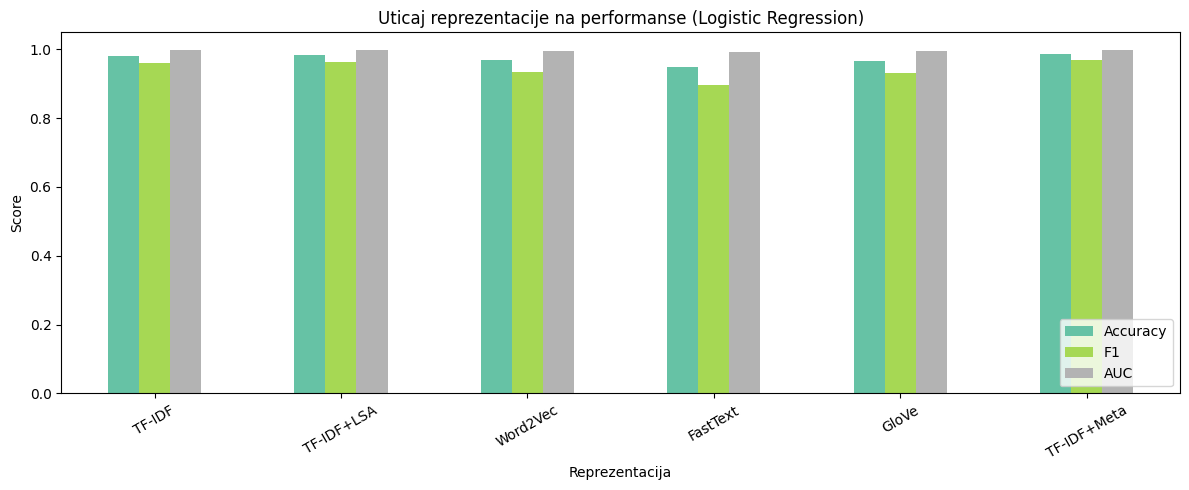

In [207]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr = LogisticRegression(max_iter=1000, random_state=42)

repr_results = []

repr_list = [
    ('TF-IDF',        X_train_tfidf,    X_test_tfidf),
    ('TF-IDF+LSA',    X_train_lsa,      X_test_lsa),
    ('Word2Vec',      X_train_w2v,      X_test_w2v),
    ('FastText',      X_train_ft,       X_test_ft),
    ('GloVe',         X_train_glove,    X_test_glove),
    ('TF-IDF+Meta',   X_train_combined, X_test_combined),
]

for name, X_tr, X_te in repr_list:
    # Dense matrice skalirati
    if hasattr(X_tr, 'toarray'):
        X_tr_fit = X_tr
        X_te_fit = X_te
    else:
        scaler = StandardScaler()
        X_tr_fit = scaler.fit_transform(X_tr)
        X_te_fit = scaler.transform(X_te)
    
    lr.fit(X_tr_fit, y_train)
    y_pred = lr.predict(X_te_fit)
    
    try:
        prob = lr.predict_proba(X_te_fit)[:,1]
    except:
        prob = lr.decision_function(X_te_fit)
    
    repr_results.append({
        'Reprezentacija': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1':       f1_score(y_test, y_pred),
        'AUC':      roc_auc_score(y_test, prob)
    })

repr_df = pd.DataFrame(repr_results)
display(repr_df.round(4))

# Vizuelizacija
repr_df.set_index('Reprezentacija')[['Accuracy','F1','AUC']].plot(
    kind='bar', figsize=(12,5), colormap='Set2'
)
plt.title("Uticaj reprezentacije na performanse (Logistic Regression)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Uticaj predobrade na isti model

,Predobrada,Accuracy,F1,AUC
0,Raw,0.9817,0.9607,0.9986
1,Normalized,0.9782,0.9529,0.9983
2,No stopwords,0.9808,0.9590,0.9989
3,Stemmed,0.9825,0.9627,0.9988
4,Lemmatized,0.9764,0.9490,0.9987


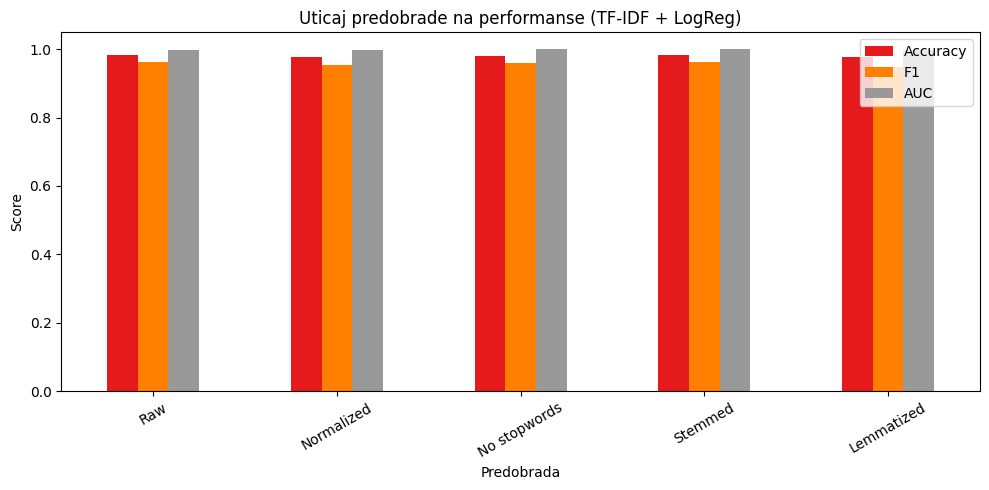

In [208]:
preproc_results = []

preproc_list = [
    ('Raw',         df['text_raw']),
    ('Normalized',  df['text_norm']),
    ('No stopwords',df['text_nostop']),
    ('Stemmed',     df['text_stem']),
    ('Lemmatized',  df['text_lemma']),
]

for name, texts in preproc_list:
    X_tr, X_te, y_tr, y_te = train_test_split(
        texts, df['spam'], test_size=0.2, random_state=42, stratify=df['spam']
    )
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
    X_tr_v = vec.fit_transform(X_tr)
    X_te_v = vec.transform(X_te)
    
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr_v, y_tr)
    y_pred = lr.predict(X_te_v)
    prob   = lr.predict_proba(X_te_v)[:,1]
    
    preproc_results.append({
        'Predobrada':  name,
        'Accuracy':    accuracy_score(y_te, y_pred),
        'F1':          f1_score(y_te, y_pred),
        'AUC':         roc_auc_score(y_te, prob)
    })

preproc_df = pd.DataFrame(preproc_results)
display(preproc_df.round(4))

preproc_df.set_index('Predobrada')[['Accuracy','F1','AUC']].plot(
    kind='bar', figsize=(10,5), colormap='Set1'
)
plt.title("Uticaj predobrade na performanse (TF-IDF + LogReg)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Confusion Matrix i Classification Report

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       872
        Spam       0.98      0.94      0.96       274

    accuracy                           0.98      1146
   macro avg       0.98      0.97      0.97      1146
weighted avg       0.98      0.98      0.98      1146



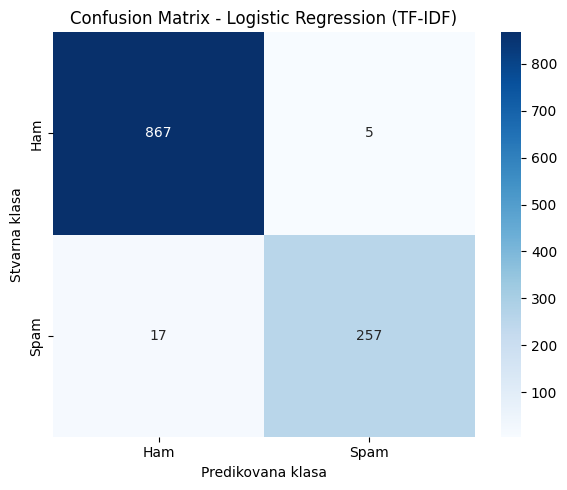

In [209]:
# Treniraj najbolji ML model (po rezultatima izaberi)
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_tfidf, y_train)
y_pred_best = best_model.predict(X_test_tfidf)

# Classification report
print(classification_report(y_test, y_pred_best, 
                             target_names=['Ham', 'Spam']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])
plt.title("Confusion Matrix - Logistic Regression (TF-IDF)")
plt.ylabel("Stvarna klasa")
plt.xlabel("Predikovana klasa")
plt.tight_layout()
plt.show()

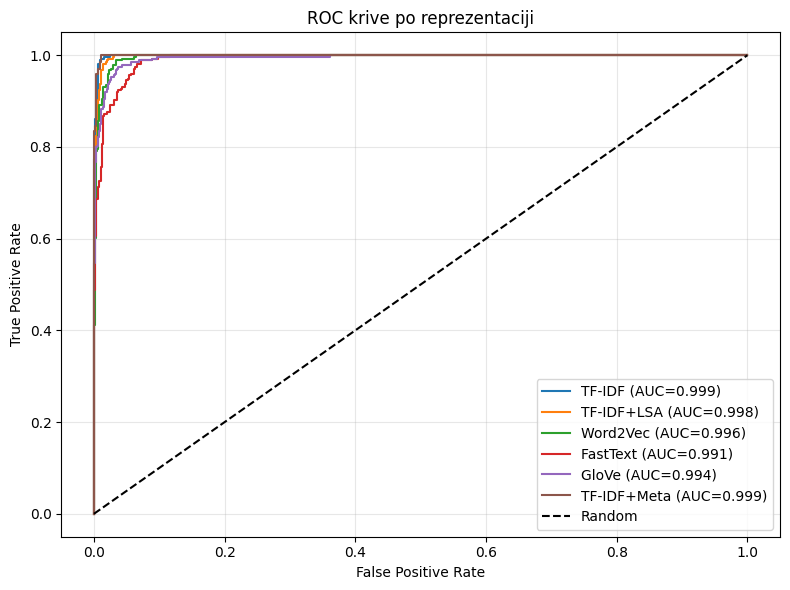

In [210]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, X_tr, X_te in repr_list:
    if hasattr(X_tr, 'toarray'):
        X_tr_fit, X_te_fit = X_tr, X_te
    else:
        scaler = StandardScaler()
        X_tr_fit = scaler.fit_transform(X_tr)
        X_te_fit = scaler.transform(X_te)
    
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr_fit, y_train)
    
    try:
        prob = lr.predict_proba(X_te_fit)[:,1]
    except:
        prob = lr.decision_function(X_te_fit)
    
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krive po reprezentaciji")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Deep Learning — LSTM

LSTM (Long Short-Term Memory) je rekurentna neuralna mreža koja može da modeluje dugoročne zavisnosti između reči u sekvenci. Za razliku od BoW i TF-IDF koji gube informaciju o redosledu reči, LSTM procesira tekst sekvencijalno i pamti kontekst.

In [211]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, 
                                      Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenizacija
MAX_VOCAB  = 10000
MAX_LEN    = 200
EMBED_DIM  = 64

tokenizer_dl = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq  = tokenizer_dl.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")

2026-03-05 16:33:51.357060: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Train shape: (4582, 200)
Test shape:  (1146, 200)


In [212]:
# LSTM model
lstm_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

/Users/milicamilutinovic/ml_nlp/tf_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [213]:
# Treniranje
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 169ms/step - accuracy: 0.8436 - loss: 0.4568 - val_accuracy: 0.9673 - val_loss: 0.1529
Epoch 2/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.9821 - loss: 0.0615 - val_accuracy: 0.9847 - val_loss: 0.0411
Epoch 3/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9988 - loss: 0.0077 - val_accuracy: 0.9891 - val_loss: 0.0299
Epoch 4/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.9990 - loss: 0.0055 - val_accuracy: 0.9956 - val_loss: 0.0154
Epoch 5/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9990 - loss: 0.0048 - val_accuracy: 0.9891 - val_loss: 0.0435


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
              precision    recall  f1-score   support

         Ham       1.00      0.99      0.99       872
        Spam       0.96      0.99      0.97       274

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.98      1146
weighted avg       0.99      0.99      0.99      1146

AUC: 0.9991


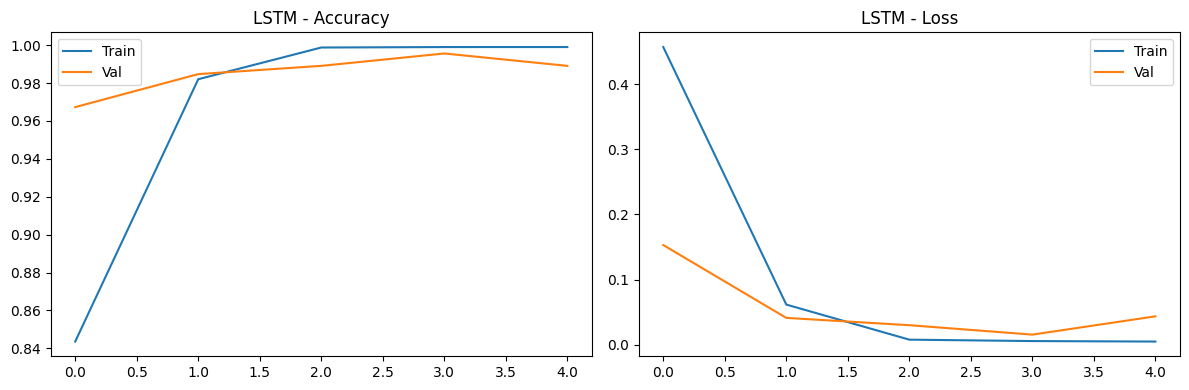

In [214]:
# Evaluacija
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()
y_prob_lstm = lstm_model.predict(X_test_pad).flatten()

print(classification_report(y_test, y_pred_lstm, target_names=['Ham','Spam']))
print(f"AUC: {roc_auc_score(y_test, y_prob_lstm):.4f}")
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm.history['accuracy'],     label='Train')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val')
axes[0].set_title("LSTM - Accuracy")
axes[0].legend()

axes[1].plot(history_lstm.history['loss'],     label='Train')
axes[1].plot(history_lstm.history['val_loss'], label='Val')
axes[1].set_title("LSTM - Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


### Deep Learning — CNN za tekst

CNN (Convolutional Neural Network) za tekst koristi 1D konvolucije koje detektuju lokalne n-gram obrasce. Brži je od LSTM i često postiže slične ili bolje rezultate na zadacima klasifikacije teksta.

In [215]:
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D

cnn_model = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

y_pred_cnn = (cnn_model.predict(X_test_pad) > 0.5).astype(int).flatten()
y_prob_cnn  = cnn_model.predict(X_test_pad).flatten()

print(classification_report(y_test, y_pred_cnn, target_names=['Ham','Spam']))
print(f"AUC: {roc_auc_score(y_test, y_prob_cnn):.4f}")

Epoch 1/5


/Users/milicamilutinovic/ml_nlp/tf_env/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8225 - loss: 0.3506 - val_accuracy: 0.9651 - val_loss: 0.1573
Epoch 2/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9789 - loss: 0.0731 - val_accuracy: 0.9891 - val_loss: 0.0396
Epoch 3/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9954 - loss: 0.0201 - val_accuracy: 0.9935 - val_loss: 0.0180
Epoch 4/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9990 - loss: 0.0065 - val_accuracy: 0.9913 - val_loss: 0.0151
Epoch 5/5
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9998 - loss: 0.0028 - val_accuracy: 0.9935 - val_loss: 0.0160
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

         Ham       1.00      0.99      0.99       872
        Spam       0.96      0.99      0.98       274

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0

In [219]:
acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm  = f1_score(y_test, y_pred_lstm)
auc_lstm = roc_auc_score(y_test, y_prob_lstm)

acc_cnn = accuracy_score(y_test, y_pred_cnn)
f1_cnn  = f1_score(y_test, y_pred_cnn)
auc_cnn = roc_auc_score(y_test, y_prob_cnn)

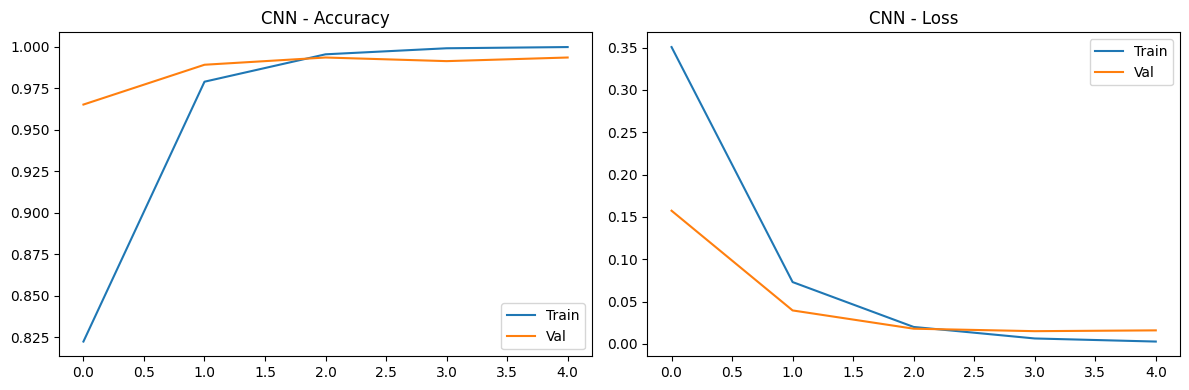

In [225]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_cnn.history['accuracy'], label='Train')
axes[0].plot(history_cnn.history['val_accuracy'], label='Val')
axes[0].set_title("CNN - Accuracy")
axes[0].legend()

axes[1].plot(history_cnn.history['loss'], label='Train')
axes[1].plot(history_cnn.history['val_loss'], label='Val')
axes[1].set_title("CNN - Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

,Model,Reprezentacija,Accuracy,F1,AUC
10,CNN (1D),Embedding,0.9895,0.9784,0.9983
3,LinearSVC,TF-IDF,0.9895,0.9781,0.9995
9,LSTM (Bidirectional),Embedding,0.9878,0.9749,0.9991
8,Logistic Regression,TF-IDF+Meta,0.9852,0.9683,0.9992
4,Random Forest,TF-IDF,0.9843,0.9669,0.9981
1,Naive Bayes,TF-IDF,0.9843,0.9669,0.9983
2,Logistic Regression,TF-IDF,0.9808,0.9590,0.9989
5,Logistic Regression,Word2Vec,0.9686,0.9343,0.9957
7,Logistic Regression,GloVe,0.9668,0.9296,0.9940
6,Logistic Regression,FastText,0.9494,0.8949,0.9910


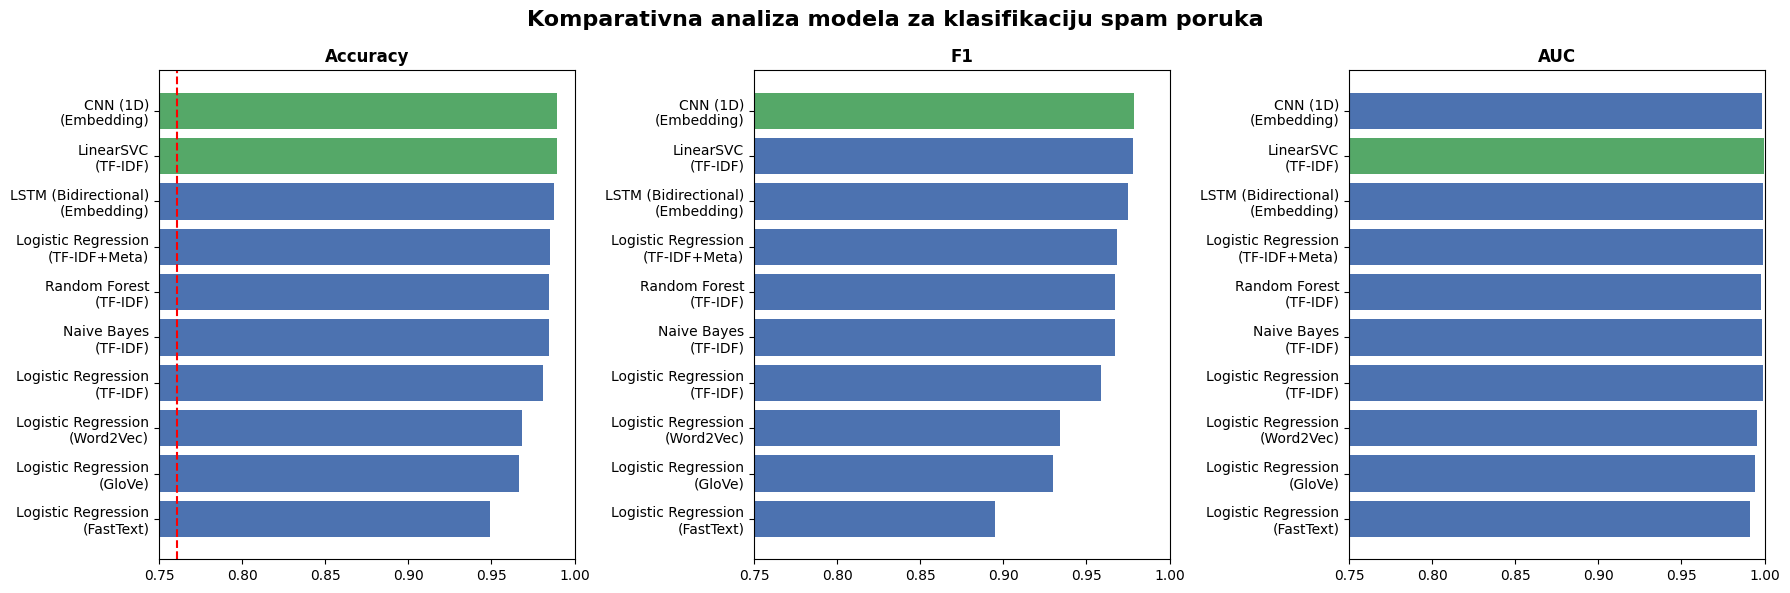

In [223]:
final_results = pd.DataFrame([
    {'Model': 'Baseline (Majority)', 'Reprezentacija': '-', 
     'Accuracy': accuracy_score(y_test, y_pred_dummy), 'F1': 0.0, 'AUC': 0.5},

    {'Model': 'Naive Bayes', 'Reprezentacija': 'TF-IDF',
     'Accuracy': ml_df.loc[ml_df.Model=='Naive Bayes','Accuracy'].values[0],
     'F1': ml_df.loc[ml_df.Model=='Naive Bayes','F1'].values[0],
     'AUC': ml_df.loc[ml_df.Model=='Naive Bayes','AUC'].values[0]},

    {'Model': 'Logistic Regression', 'Reprezentacija': 'TF-IDF',
     'Accuracy': ml_df.loc[ml_df.Model=='Logistic Regression','Accuracy'].values[0],
     'F1': ml_df.loc[ml_df.Model=='Logistic Regression','F1'].values[0],
     'AUC': ml_df.loc[ml_df.Model=='Logistic Regression','AUC'].values[0]},

    {'Model': 'LinearSVC', 'Reprezentacija': 'TF-IDF',
     'Accuracy': ml_df.loc[ml_df.Model=='LinearSVC','Accuracy'].values[0],
     'F1': ml_df.loc[ml_df.Model=='LinearSVC','F1'].values[0],
     'AUC': ml_df.loc[ml_df.Model=='LinearSVC','AUC'].values[0]},

    {'Model': 'Random Forest', 'Reprezentacija': 'TF-IDF',
     'Accuracy': ml_df.loc[ml_df.Model=='Random Forest','Accuracy'].values[0],
     'F1': ml_df.loc[ml_df.Model=='Random Forest','F1'].values[0],
     'AUC': ml_df.loc[ml_df.Model=='Random Forest','AUC'].values[0]},

    {'Model': 'Logistic Regression', 'Reprezentacija': 'Word2Vec',
     'Accuracy': repr_df.loc[repr_df.Reprezentacija=='Word2Vec','Accuracy'].values[0],
     'F1': repr_df.loc[repr_df.Reprezentacija=='Word2Vec','F1'].values[0],
     'AUC': repr_df.loc[repr_df.Reprezentacija=='Word2Vec','AUC'].values[0]},

    {'Model': 'Logistic Regression', 'Reprezentacija': 'FastText',
     'Accuracy': repr_df.loc[repr_df.Reprezentacija=='FastText','Accuracy'].values[0],
     'F1': repr_df.loc[repr_df.Reprezentacija=='FastText','F1'].values[0],
     'AUC': repr_df.loc[repr_df.Reprezentacija=='FastText','AUC'].values[0]},

    {'Model': 'Logistic Regression', 'Reprezentacija': 'GloVe',
     'Accuracy': repr_df.loc[repr_df.Reprezentacija=='GloVe','Accuracy'].values[0],
     'F1': repr_df.loc[repr_df.Reprezentacija=='GloVe','F1'].values[0],
     'AUC': repr_df.loc[repr_df.Reprezentacija=='GloVe','AUC'].values[0]},

    {'Model': 'Logistic Regression', 'Reprezentacija': 'TF-IDF+Meta',
     'Accuracy': repr_df.loc[repr_df.Reprezentacija=='TF-IDF+Meta','Accuracy'].values[0],
     'F1': repr_df.loc[repr_df.Reprezentacija=='TF-IDF+Meta','F1'].values[0],
     'AUC': repr_df.loc[repr_df.Reprezentacija=='TF-IDF+Meta','AUC'].values[0]},

    {'Model': 'LSTM (Bidirectional)', 'Reprezentacija': 'Embedding',
     'Accuracy': acc_lstm, 'F1': f1_lstm, 'AUC': auc_lstm},

    {'Model': 'CNN (1D)', 'Reprezentacija': 'Embedding',
     'Accuracy': acc_cnn, 'F1': f1_cnn, 'AUC': auc_cnn},
])

display(final_results.sort_values('F1', ascending=False).round(4))

# Vizuelizacija
plot_df = final_results.copy()

# ukloni baseline iz barova
baseline_acc = plot_df.iloc[0]["Accuracy"]
baseline_f1  = plot_df.iloc[0]["F1"]
baseline_auc = plot_df.iloc[0]["AUC"]

plot_df = plot_df.iloc[1:]

# sortiranje po F1
plot_df = plot_df.sort_values("F1")

fig, axes = plt.subplots(1,3, figsize=(18,6))

metrics = ["Accuracy","F1","AUC"]
baselines = [baseline_acc, baseline_f1, baseline_auc]

for ax, metric, base in zip(axes, metrics, baselines):

    colors = ["#55A868" if v==plot_df[metric].max() else "#4C72B0"
              for v in plot_df[metric]]

    ax.barh(plot_df["Model"] + "\n(" + plot_df["Reprezentacija"] + ")",
            plot_df[metric],
            color=colors)

    ax.axvline(base, color="red", linestyle="--", label="Baseline")
    ax.set_title(metric, fontweight="bold")
    ax.set_xlim(0.75,1.0)

plt.suptitle("Komparativna analiza modela za klasifikaciju spam poruka",
             fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()


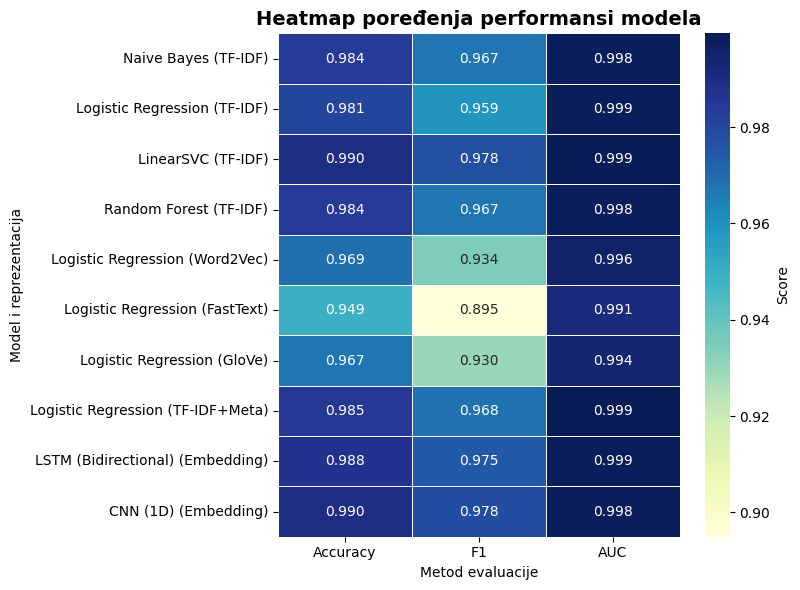

In [224]:
heat_df = final_results.copy()
heat_df = heat_df[heat_df["Model"] != "Baseline (Majority)"]

# kombinovana oznaka model + reprezentacija
heat_df["Model + Repr"] = heat_df["Model"] + " (" + heat_df["Reprezentacija"] + ")"

# matrica za heatmap
heat_matrix = heat_df.set_index("Model + Repr")[["Accuracy","F1","AUC"]]

plt.figure(figsize=(8,6))

sns.heatmap(
    heat_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
)

plt.title("Heatmap poređenja performansi modela", fontsize=14, fontweight="bold")
plt.ylabel("Model i reprezentacija")
plt.xlabel("Metod evaluacije")

plt.tight_layout()
plt.show()

# 6. Uticaj predobrade na performanse modela

In [226]:
preproc_svc_results = []

preproc_list = [
    ('Raw',          df['text_raw']),
    ('Normalized',   df['text_norm']),
    ('No stopwords', df['text_nostop']),
    ('Stemmed',      df['text_stem']),
    ('Lemmatized',   df['text_lemma']),
]

for name, texts in preproc_list:
    X_tr, X_te, y_tr, y_te = train_test_split(
        texts, df['spam'], test_size=0.2, 
        random_state=42, stratify=df['spam']
    )
    vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
    X_tr_v = vec.fit_transform(X_tr)
    X_te_v  = vec.transform(X_te)
    
    svc = LinearSVC(max_iter=1000)
    svc.fit(X_tr_v, y_tr)
    y_pred = svc.predict(X_te_v)
    prob   = svc.decision_function(X_te_v)
    
    preproc_svc_results.append({
        'Predobrada': name,
        'Accuracy':   accuracy_score(y_te, y_pred),
        'F1':         f1_score(y_te, y_pred),
        'AUC':        roc_auc_score(y_te, prob)
    })

preproc_svc_df = pd.DataFrame(preproc_svc_results)
display(preproc_svc_df.round(4))

,Predobrada,Accuracy,F1,AUC
0,Raw,0.9878,0.9745,0.9996
1,Normalized,0.9878,0.9744,0.9995
2,No stopwords,0.9895,0.9781,0.9995
3,Stemmed,0.9895,0.9780,0.9993
4,Lemmatized,0.9895,0.9781,0.9995


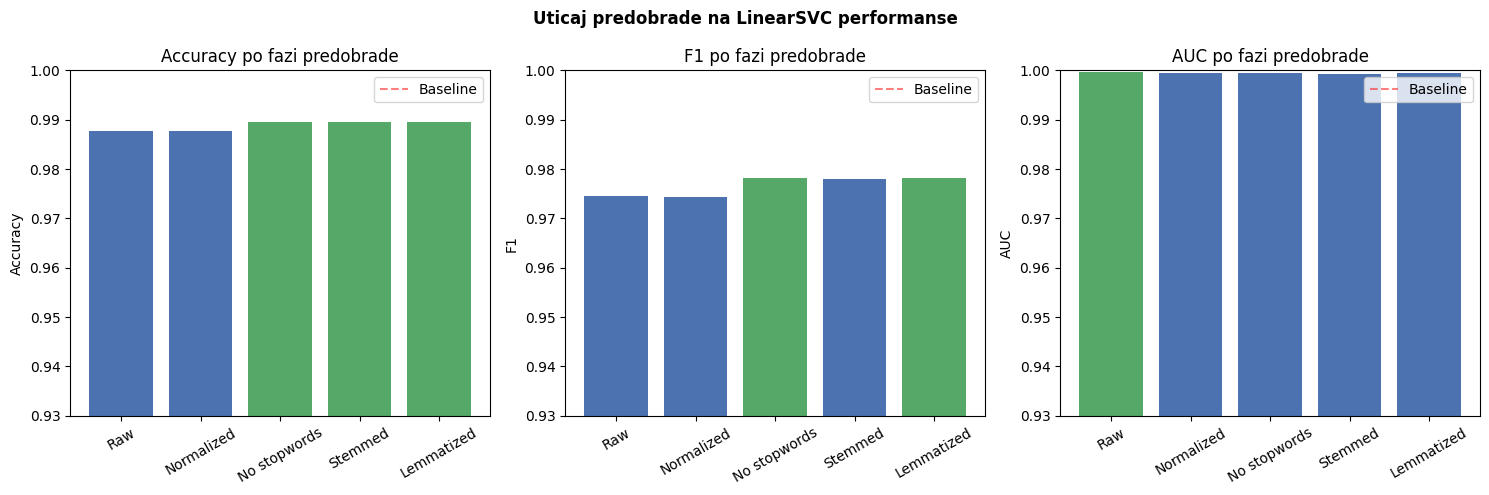

In [227]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1', 'AUC']):
    colors = ['#55A868' if v == preproc_svc_df[metric].max() 
              else '#4C72B0' for v in preproc_svc_df[metric]]
    ax.bar(preproc_svc_df['Predobrada'], 
           preproc_svc_df[metric], color=colors)
    ax.set_title(f"{metric} po fazi predobrade")
    ax.set_ylabel(metric)
    ax.set_ylim(0.93, 1.0)
    ax.tick_params(axis='x', rotation=30)
    # Baseline linija
    ax.axhline(y=0.76, color='red', linestyle='--', 
               label='Baseline', alpha=0.5)
    ax.legend()

plt.suptitle("Uticaj predobrade na LinearSVC performanse", 
             fontweight='bold')
plt.tight_layout()
plt.show()

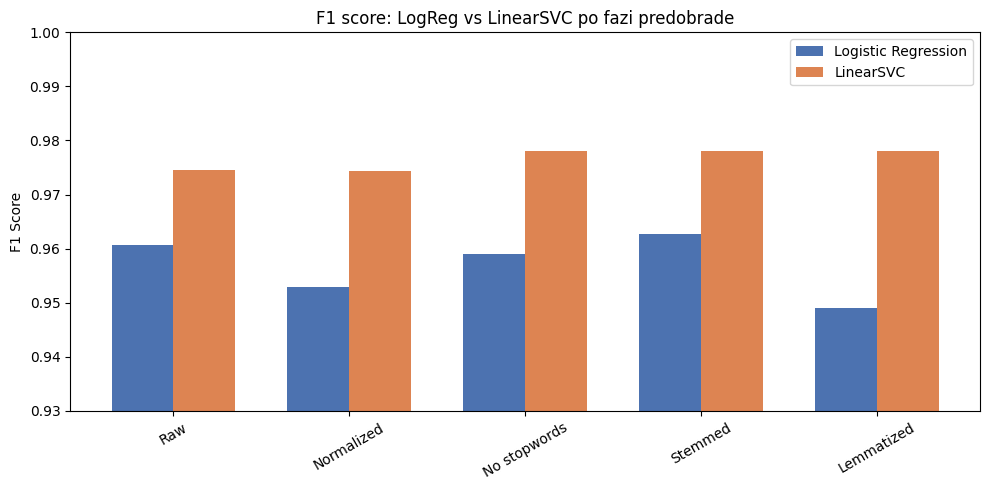

In [228]:
# Kombinovano poređenje LogReg vs LinearSVC
comparison_df = preproc_df.copy()
comparison_df.columns = ['Predobrada', 'LR_Acc', 'LR_F1', 'LR_AUC']
comparison_df['SVC_Acc'] = preproc_svc_df['Accuracy'].values
comparison_df['SVC_F1']  = preproc_svc_df['F1'].values
comparison_df['SVC_AUC'] = preproc_svc_df['AUC'].values

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['LR_F1'],  width, 
       label='Logistic Regression', color='#4C72B0')
ax.bar(x + width/2, comparison_df['SVC_F1'], width, 
       label='LinearSVC', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Predobrada'], rotation=30)
ax.set_title("F1 score: LogReg vs LinearSVC po fazi predobrade")
ax.set_ylabel("F1 Score")
ax.set_ylim(0.93, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

## Uticaj augmentacije na performanse

In [229]:
from sklearn.model_selection import train_test_split

aug_results = []

# --- Bez augmentacije ---
X_orig = df['text_nostop']
y_orig = df['spam']

X_tr_o, X_te_o, y_tr_o, y_te_o = train_test_split(
    X_orig, y_orig, test_size=0.2, 
    random_state=42, stratify=y_orig
)

vec_o = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_tr_o_v = vec_o.fit_transform(X_tr_o)
X_te_o_v = vec_o.transform(X_te_o)

for name, model in [
    ('Naive Bayes',         MultinomialNB()),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('LinearSVC',           LinearSVC(max_iter=1000)),
]:
    model.fit(X_tr_o_v, y_tr_o)
    y_pred = model.predict(X_te_o_v)
    aug_results.append({
        'Model':      name,
        'Augmentacija': 'Bez augmentacije',
        'F1':         f1_score(y_te_o, y_pred),
        'Accuracy':   accuracy_score(y_te_o, y_pred),
        'Recall_spam': classification_report(
            y_te_o, y_pred, output_dict=True)['1']['recall']
    })

# --- Sa augmentacijom ---
X_aug = df_augmented['text_nostop']
y_aug = df_augmented['spam']

# Test skup je isti originalni (važno!)
X_tr_a = X_aug  
y_tr_a = y_aug

vec_a = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_tr_a_v = vec_a.fit_transform(X_tr_a)
X_te_a_v = vec_a.transform(X_te_o)  # isti test skup!

for name, model in [
    ('Naive Bayes',         MultinomialNB()),
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('LinearSVC',           LinearSVC(max_iter=1000)),
]:
    model.fit(X_tr_a_v, y_tr_a)
    y_pred = model.predict(X_te_a_v)
    aug_results.append({
        'Model':       name,
        'Augmentacija': 'Sa augmentacijom',
        'F1':          f1_score(y_te_o, y_pred),
        'Accuracy':    accuracy_score(y_te_o, y_pred),
        'Recall_spam': classification_report(
            y_te_o, y_pred, output_dict=True)['1']['recall']
    })

aug_df = pd.DataFrame(aug_results)
display(aug_df.round(4))

,Model,Augmentacija,F1,Accuracy,Recall_spam
0,Naive Bayes,Bez augmentacije,0.9669,0.9843,0.9599
1,Logistic Regression,Bez augmentacije,0.9590,0.9808,0.9380
2,LinearSVC,Bez augmentacije,0.9781,0.9895,0.9781
3,Naive Bayes,Sa augmentacijom,0.9836,0.9921,0.9854
4,Logistic Regression,Sa augmentacijom,0.9927,0.9965,0.9964
5,LinearSVC,Sa augmentacijom,1.0000,1.0000,1.0000


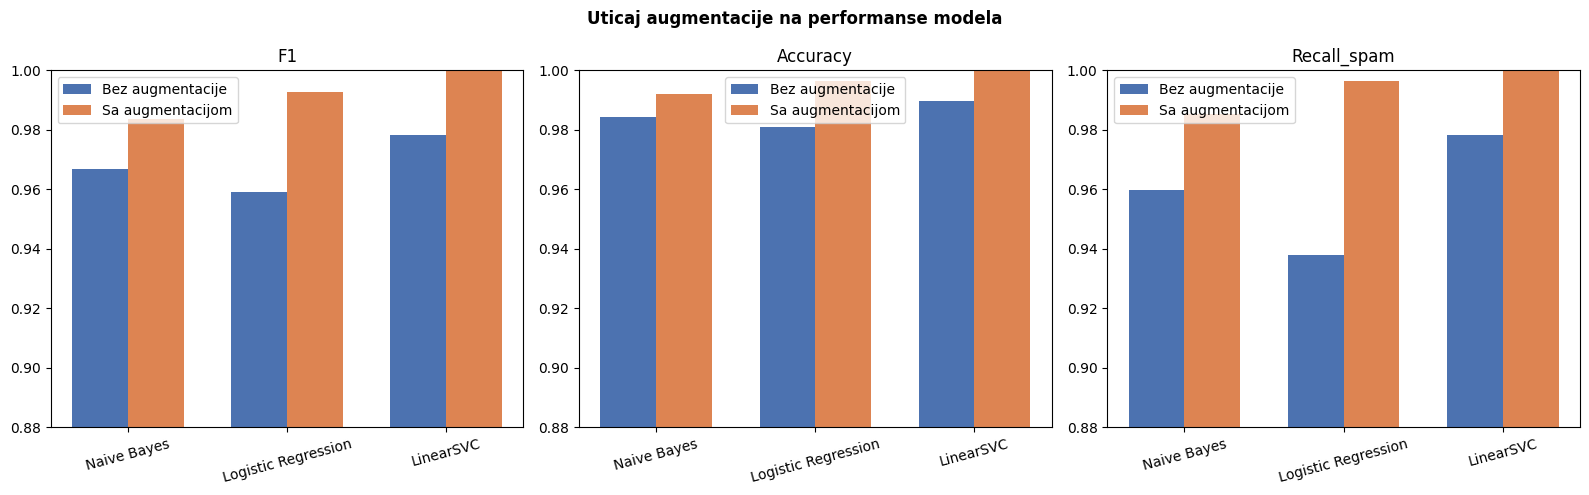

In [230]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['F1', 'Accuracy', 'Recall_spam']):
    models   = aug_df['Model'].unique()
    x        = np.arange(len(models))
    width    = 0.35
    
    bez = aug_df[aug_df['Augmentacija']=='Bez augmentacije'][metric].values
    sa  = aug_df[aug_df['Augmentacija']=='Sa augmentacijom'][metric].values
    
    ax.bar(x - width/2, bez, width, label='Bez augmentacije', 
           color='#4C72B0')
    ax.bar(x + width/2, sa,  width, label='Sa augmentacijom',  
           color='#DD8452')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_title(metric)
    ax.set_ylim(0.88, 1.0)
    ax.legend()

plt.suptitle("Uticaj augmentacije na performanse modela", 
             fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretabilnost modela (XAI)

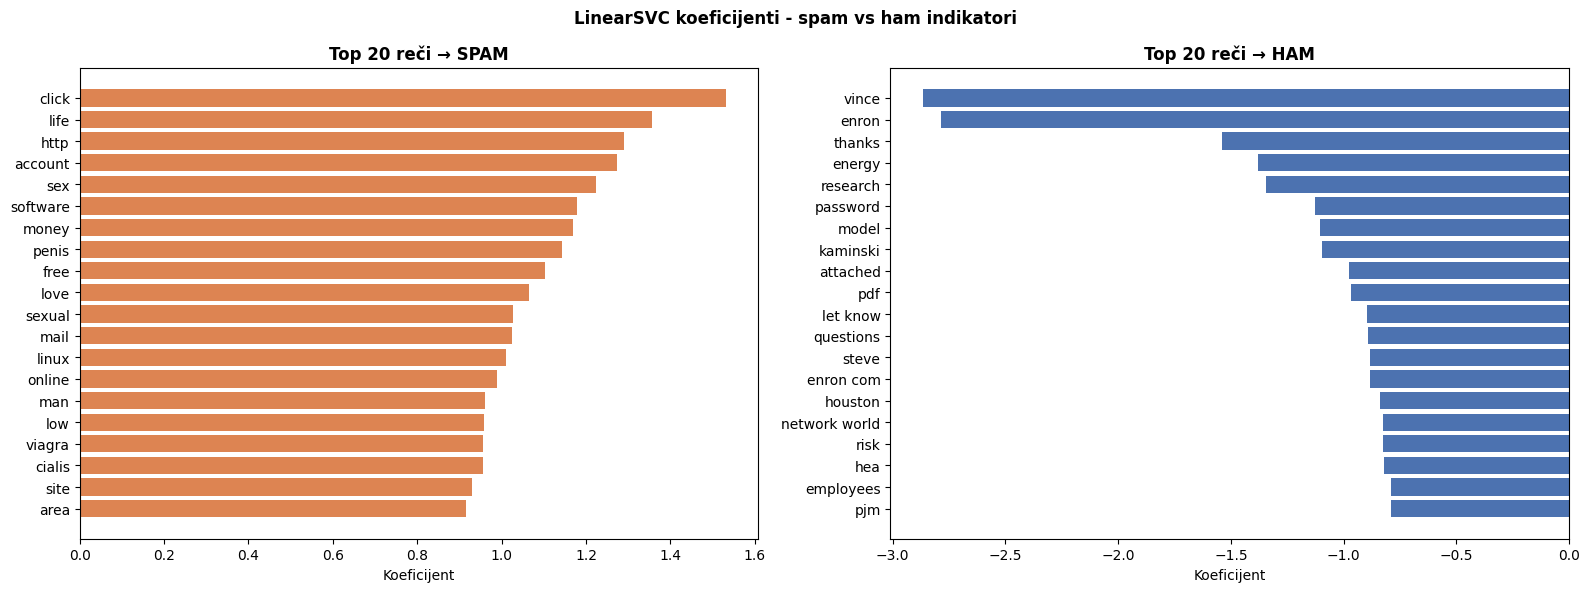

In [231]:
# Treniraj LinearSVC na TF-IDF
svc_xai = LinearSVC(max_iter=1000)
svc_xai.fit(X_train_tfidf, y_train)

feature_names_xai = tfidf_full.get_feature_names_out()
coefs = svc_xai.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names_xai,
    'coefficient': coefs
}).sort_values('coefficient', ascending=False)

top_spam = coef_df.head(20)
top_ham  = coef_df.tail(20).sort_values('coefficient')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_spam['feature'], top_spam['coefficient'], 
             color='#DD8452')
axes[0].set_title("Top 20 reči → SPAM", fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel("Koeficijent")

axes[1].barh(top_ham['feature'], top_ham['coefficient'], 
             color='#4C72B0')
axes[1].set_title("Top 20 reči → HAM", fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlabel("Koeficijent")

plt.suptitle("LinearSVC koeficijenti - spam vs ham indikatori", 
             fontweight='bold')
plt.tight_layout()
plt.show()

### LIME

LIME objašnjenje za SPAM email:
Tekst (skraćeno): subject good day friend dear friend salim ibrahim merchant dubai u e diagnosed esophageal cancer defiled forms medical treatment right months live acc



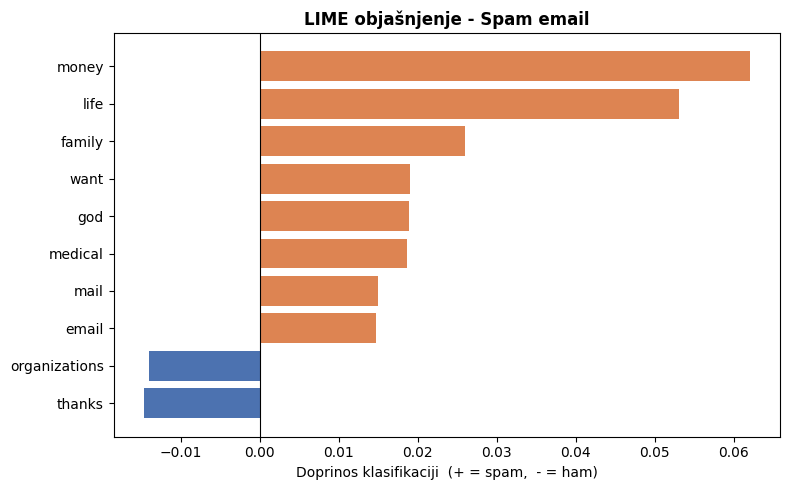

LIME objašnjenje za HAM email:
Tekst (skraćeno): subject sap time sheets o research common drive hello able access spreadsheet created time o research common sap timesheets site let know box came rea



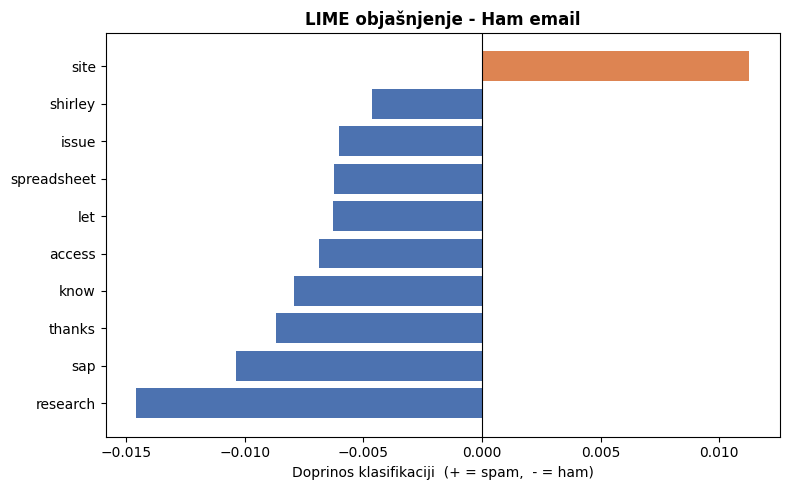

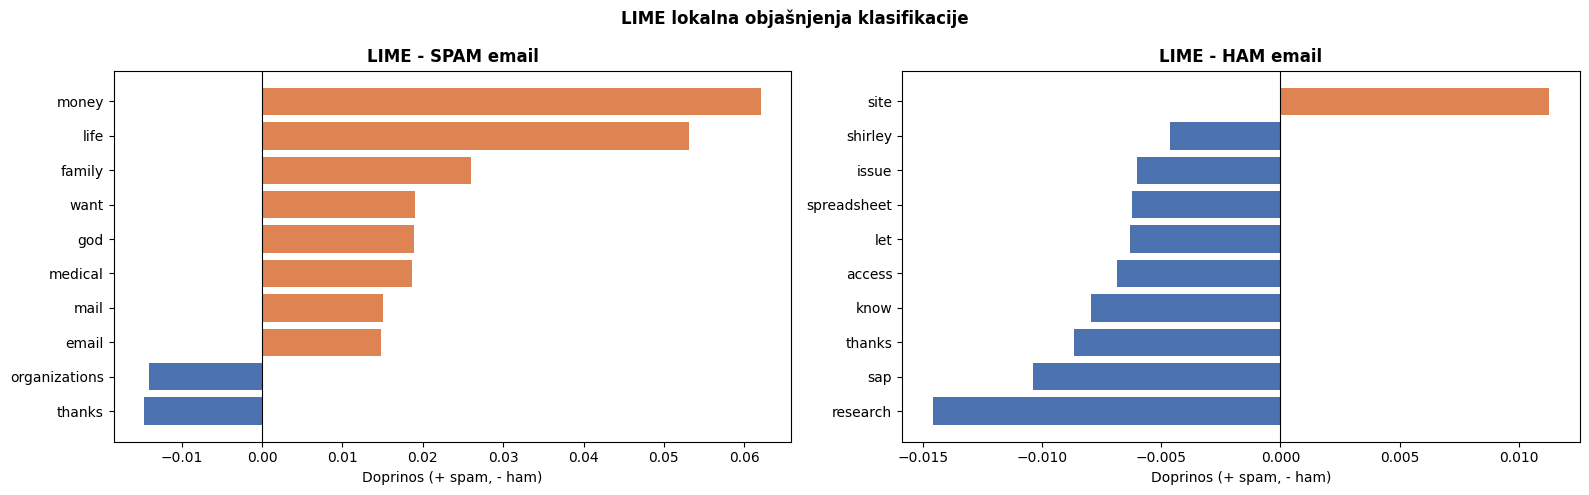

In [240]:

# SPAM primer
spam_sample = X_test[y_test == 1].iloc[0]
exp_spam = explainer.explain_instance(
    spam_sample,
    pipeline_cal.predict_proba,
    num_features=10
)

print("LIME objašnjenje za SPAM email:")
print(f"Tekst (skraćeno): {spam_sample[:150]}\n")

spam_features = exp_spam.as_list()
spam_feat_df  = pd.DataFrame(spam_features, columns=['Reč', 'Važnost'])
spam_feat_df  = spam_feat_df.sort_values('Važnost')
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in spam_feat_df['Važnost']]

plt.figure(figsize=(8, 5))
plt.barh(spam_feat_df['Reč'], spam_feat_df['Važnost'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("LIME objašnjenje - Spam email", fontweight='bold')
plt.xlabel("Doprinos klasifikaciji  (+ = spam,  - = ham)")
plt.tight_layout()
plt.show()

# HAM primer
ham_sample = X_test[y_test == 0].iloc[0]
exp_ham = explainer.explain_instance(
    ham_sample,
    pipeline_cal.predict_proba,
    num_features=10
)

print("LIME objašnjenje za HAM email:")
print(f"Tekst (skraćeno): {ham_sample[:150]}\n")

ham_features = exp_ham.as_list()
ham_feat_df  = pd.DataFrame(ham_features, columns=['Reč', 'Važnost'])
ham_feat_df  = ham_feat_df.sort_values('Važnost')
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in ham_feat_df['Važnost']]

plt.figure(figsize=(8, 5))
plt.barh(ham_feat_df['Reč'], ham_feat_df['Važnost'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("LIME objašnjenje - Ham email", fontweight='bold')
plt.xlabel("Doprinos klasifikaciji  (+ = spam,  - = ham)")
plt.tight_layout()
plt.show()

# Poređenje spam vs ham u jednom plotu
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, feat_df, title in zip(
    axes,
    [spam_feat_df, ham_feat_df],
    ["SPAM email", "HAM email"]
):
    colors = ['#DD8452' if v > 0 else '#4C72B0' for v in feat_df['Važnost']]
    ax.barh(feat_df['Reč'], feat_df['Važnost'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"LIME - {title}", fontweight='bold')
    ax.set_xlabel("Doprinos (+ spam, - ham)")

plt.suptitle("LIME lokalna objašnjenja klasifikacije", fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Vizuelizacija LIME kao bar chart
spam_features = exp_spam.as_list()
spam_feat_df  = pd.DataFrame(spam_features, 
                              columns=['Reč', 'Važnost'])
spam_feat_df  = spam_feat_df.sort_values('Važnost')

colors = ['#DD8452' if v > 0 else '#4C72B0' 
          for v in spam_feat_df['Važnost']]

plt.figure(figsize=(8, 5))
plt.barh(spam_feat_df['Reč'], spam_feat_df['Važnost'], 
         color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("LIME objašnjenje - Spam email", fontweight='bold')
plt.xlabel("Doprinos klasifikaciji (+ = spam, - = ham)")
plt.tight_layout()
plt.show()

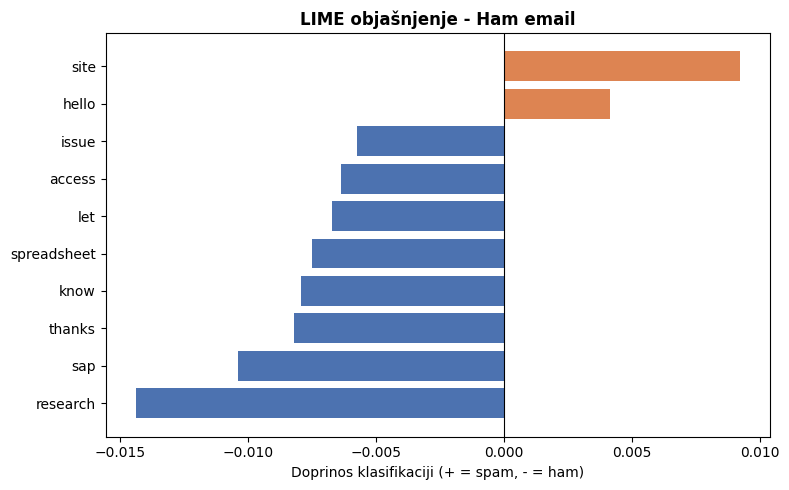

In [233]:
# Objasni jedan ham primer
ham_sample = X_test[y_test == 0].iloc[0]
exp_ham = explainer.explain_instance(
    ham_sample,
    pipeline_cal.predict_proba,
    num_features=10
)

ham_features = exp_ham.as_list()
ham_feat_df  = pd.DataFrame(ham_features, 
                              columns=['Reč', 'Važnost'])
ham_feat_df  = ham_feat_df.sort_values('Važnost')

colors = ['#DD8452' if v > 0 else '#4C72B0' 
          for v in ham_feat_df['Važnost']]

plt.figure(figsize=(8, 5))
plt.barh(ham_feat_df['Reč'], ham_feat_df['Važnost'], 
         color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("LIME objašnjenje - Ham email", fontweight='bold')
plt.xlabel("Doprinos klasifikaciji (+ = spam, - = ham)")
plt.tight_layout()
plt.show()

###  Permutation Importance

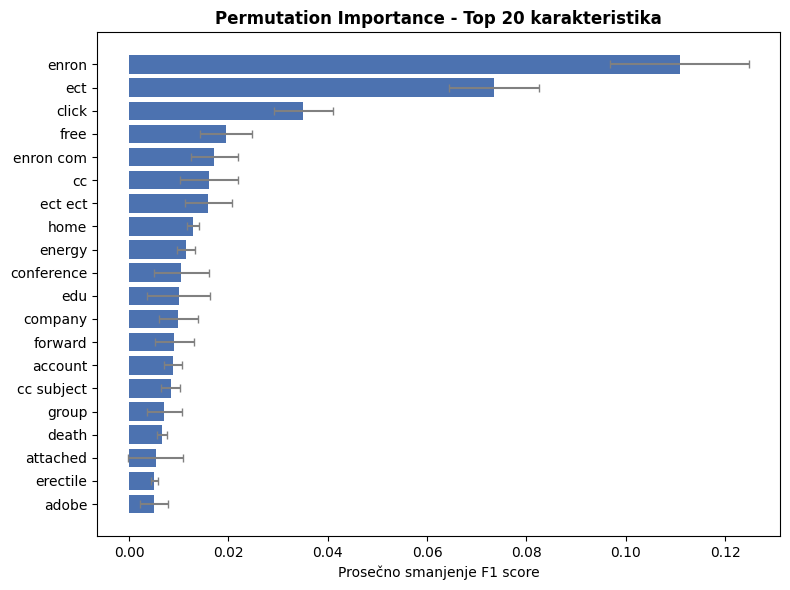

In [238]:
from sklearn.inspection import permutation_importance
top_features = 2000

X_train_small = X_train_tfidf[:, :top_features]
X_test_small  = X_test_tfidf[:, :top_features]

X_train_dense = X_train_small.toarray()
X_test_dense  = X_test_small.toarray()

lr_xai = LogisticRegression(max_iter=1000, random_state=42)
lr_xai.fit(X_train_dense, y_train)

perm = permutation_importance(
    lr_xai,
    X_test_dense,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='f1',
    n_jobs=-1
)

# Top feature indeksi
feature_names_xai = tfidf_full.get_feature_names_out()
top_idx = perm.importances_mean.argsort()[-20:]

top_perm_df = pd.DataFrame({
    'feature':    feature_names_xai[top_idx],
    'importance': perm.importances_mean[top_idx],
    'std':        perm.importances_std[top_idx]
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_perm_df['feature'], top_perm_df['importance'],
         xerr=top_perm_df['std'], color='#4C72B0',
         ecolor='gray', capsize=3)
plt.title("Permutation Importance - Top 20 karakteristika",
          fontweight='bold')
plt.xlabel("Prosečno smanjenje F1 score")
plt.tight_layout()
plt.show()

# 7. Finalni pregled

In [242]:
# === 1. COLORS ===
COLORS = ['#4C72B0', '#DD8452']

# === 2. TTR kolona ===
df['ttr'] = df['lexical_diversity']  # već imaš ovo

# === 3. vocab_sizes za ax5 ===
# Ovo treba da bude dict sa 5 vrednosti
from sklearn.feature_extraction.text import CountVectorizer

vocab_sizes = {
    'Bez norm.':  len(CountVectorizer().fit(df['text_raw']).vocabulary_),
    'Lowercase':  len(CountVectorizer().fit(df['text_norm']).vocabulary_),
    'No stopwords': len(CountVectorizer().fit(df['text_nostop']).vocabulary_),
    'Stemmed':    len(CountVectorizer().fit(df['text_stem']).vocabulary_),
    'Lemmatized': len(CountVectorizer().fit(df['text_lemma']).vocabulary_),
}

# === 4. prep_df za ax6 — F1 po predobradi ===
prep_df = preproc_df.copy()  # već imaš preproc_df iz sekcije 5.4
prep_df.columns = ['predobrada', 'accuracy', 'f1', 'auc']
prep_df = prep_df.reset_index(drop=True)

# === 5. results_df za ax7 — F1 po modelu ===
results_df = pd.DataFrame({
    'model': ['Baseline', 'Naive Bayes', 'Logistic Reg.', 
              'LinearSVC', 'Random Forest', 'CNN'],
    'f1':    [0.000, 0.967, 0.959, 0.978, 0.967, 0.978]
}).set_index('model')

# === 6. vocab_res_df za ax8 — vokabular vs F1 ===
from sklearn.linear_model import LogisticRegression

vocab_res_list = []
for max_f in [100, 500, 1000, 2000, 5000, 10000]:
    vec = TfidfVectorizer(max_features=max_f, ngram_range=(1,2), min_df=2)
    X_tr_v = vec.fit_transform(X_train)
    X_te_v = vec.transform(X_test)
    lr_tmp = LogisticRegression(max_iter=1000, random_state=42)
    lr_tmp.fit(X_tr_v, y_train)
    y_pred_tmp = lr_tmp.predict(X_te_v)
    vocab_res_list.append({
        'max_features': max_f,
        'f1': f1_score(y_test, y_pred_tmp)
    })

vocab_res_df = pd.DataFrame(vocab_res_list)

# === 7. top_spam_feats za ax9 — LR koeficijenti ===
from sklearn.linear_model import LogisticRegression

lr_coef = LogisticRegression(max_iter=1000, random_state=42)
lr_coef.fit(X_train_tfidf, y_train)

feat_names = tfidf_full.get_feature_names_out()
coefs      = lr_coef.coef_[0]

top_spam_feats = sorted(
    zip(feat_names, coefs),
    key=lambda x: x[1],
    reverse=True
)[:10]


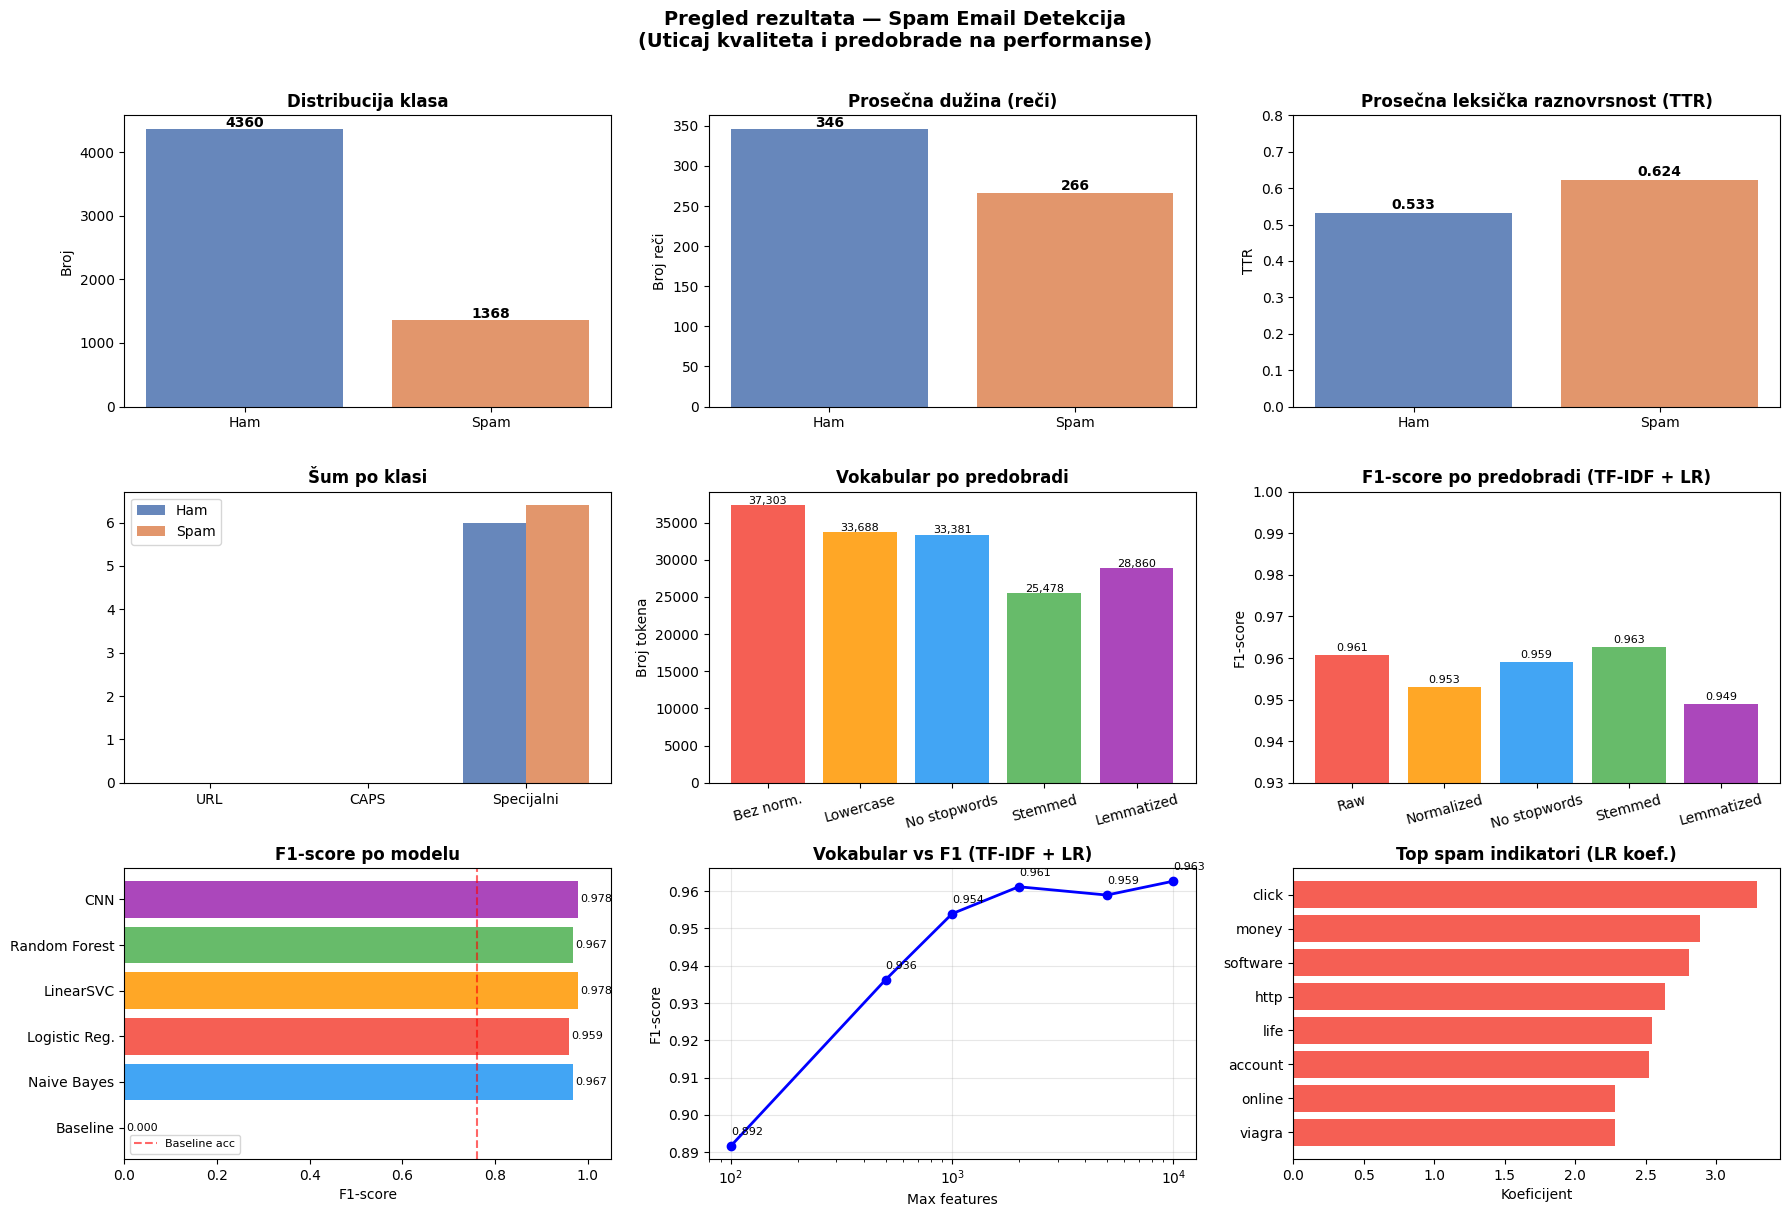

In [244]:
fig = plt.figure(figsize=(18, 12))

# 1. Distribucija klasa
ax1 = fig.add_subplot(3, 3, 1)
counts = df['spam'].value_counts()
ax1.bar(['Ham', 'Spam'], [counts[0], counts[1]], 
        color=COLORS, alpha=0.85)
ax1.set_title('Distribucija klasa', fontweight='bold')
ax1.set_ylabel('Broj')
for i, v in enumerate([counts[0], counts[1]]):
    ax1.text(i, v + 30, str(v), ha='center', fontweight='bold')

# 2. Prosečna dužina emailova
ax2 = fig.add_subplot(3, 3, 2)
means = df.groupby('spam')['word_count'].mean()
ax2.bar(['Ham', 'Spam'], means.values, color=COLORS, alpha=0.85)
ax2.set_title('Prosečna dužina (reči)', fontweight='bold')
ax2.set_ylabel('Broj reči')
for i, v in enumerate(means.values):
    ax2.text(i, v + 3, f'{v:.0f}', ha='center', fontweight='bold')

# 3. TTR po klasi
ax3 = fig.add_subplot(3, 3, 3)
ttr_means = df.groupby('spam')['ttr'].mean()
ax3.bar(['Ham', 'Spam'], ttr_means.values, color=COLORS, alpha=0.85)
ax3.set_title('Prosečna leksička raznovrsnost (TTR)', fontweight='bold')
ax3.set_ylabel('TTR')
ax3.set_ylim(0, 0.8)
for i, v in enumerate(ttr_means.values):
    ax3.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 4. Šum po klasi
ax4 = fig.add_subplot(3, 3, 4)
noise_means = df.groupby('spam')[
    ['url_count','caps_count','special_chars']
].mean()
x = np.arange(3)
ax4.bar(x - 0.2, noise_means.loc[0].values, 0.4, 
        label='Ham',  color=COLORS[0], alpha=0.85)
ax4.bar(x + 0.2, noise_means.loc[1].values, 0.4, 
        label='Spam', color=COLORS[1], alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(['URL', 'CAPS', 'Specijalni'])
ax4.set_title('Šum po klasi', fontweight='bold')
ax4.legend()

# 5. Vokabular po predobradi
ax5 = fig.add_subplot(3, 3, 5)
vocab_vals   = list(vocab_sizes.values())
vocab_labels = list(vocab_sizes.keys())
bar_colors   = ['#f44336','#ff9800','#2196F3','#4CAF50','#9C27B0']
ax5.bar(range(len(vocab_labels)), vocab_vals, 
        color=bar_colors, alpha=0.85)
ax5.set_xticks(range(len(vocab_labels)))
ax5.set_xticklabels(vocab_labels, rotation=15)
ax5.set_title('Vokabular po predobradi', fontweight='bold')
ax5.set_ylabel('Broj tokena')
for i, v in enumerate(vocab_vals):
    ax5.text(i, v + 200, f'{v:,}', ha='center', fontsize=8)

# 6. F1 po predobradi
ax6 = fig.add_subplot(3, 3, 6)
ax6.bar(range(len(prep_df)), prep_df['f1'].values,
        color=bar_colors, alpha=0.85)
ax6.set_xticks(range(len(prep_df)))
ax6.set_xticklabels(prep_df['predobrada'], rotation=15)
ax6.set_title('F1-score po predobradi (TF-IDF + LR)', fontweight='bold')
ax6.set_ylabel('F1-score')
ax6.set_ylim(0.93, 1.0)
for i, v in enumerate(prep_df['f1'].values):
    ax6.text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)

# 7. Poređenje modela — F1
ax7 = fig.add_subplot(3, 3, 7)
colors_models = ['#9E9E9E','#2196F3','#F44336',
                 '#FF9800','#4CAF50','#9C27B0']
bars = ax7.barh(results_df.index, results_df['f1'],
                color=colors_models, alpha=0.85)
ax7.set_title('F1-score po modelu', fontweight='bold')
ax7.set_xlabel('F1-score')
ax7.set_xlim(0.0, 1.05)
# Označi baseline crvenom linijom
ax7.axvline(x=0.76, color='red', linestyle='--', 
            alpha=0.6, label='Baseline acc')
ax7.legend(fontsize=8)
for bar, v in zip(bars, results_df['f1']):
    ax7.text(v + 0.005, bar.get_y() + bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=8)

# 8. Vokabular vs F1
ax8 = fig.add_subplot(3, 3, 8)
ax8.plot(vocab_res_df['max_features'], vocab_res_df['f1'], 
         'b-o', linewidth=2, markersize=6)
ax8.set_xscale('log')
ax8.set_title('Vokabular vs F1 (TF-IDF + LR)', fontweight='bold')
ax8.set_xlabel('Max features')
ax8.set_ylabel('F1-score')
ax8.grid(alpha=0.3)
for _, row in vocab_res_df.iterrows():
    ax8.annotate(f'{row.f1:.3f}', 
                 (row.max_features, row.f1),
                 textcoords='offset points',
                 xytext=(0, 8), fontsize=8)

# 9. Top spam indikatori
ax9 = fig.add_subplot(3, 3, 9)
feat_labels = [f[0] for f in top_spam_feats[:8][::-1]]
feat_vals   = [f[1] for f in top_spam_feats[:8][::-1]]
ax9.barh(feat_labels, feat_vals, color='#F44336', alpha=0.85)
ax9.set_title('Top spam indikatori (LR koef.)', fontweight='bold')
ax9.set_xlabel('Koeficijent')

plt.suptitle(
    'Pregled rezultata — Spam Email Detekcija\n'
    '(Uticaj kvaliteta i predobrade na performanse)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('fig17_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()